# Multi-resolution deconvolution of spatial transcriptomics with DestVI and Harreman

In this tutorial we apply **DestVI** (Deconvolution of Spatial Transcriptomics using Variational Inference) to a 10x Visium lymph node dataset, and then feed the deconvolution results into **Harreman** to infer cell-type-aware metabolic crosstalk.

**Why DestVI?**
Visium spots (55 µm) typically contain several cells. Most deconvolution methods return discrete cell-type proportions, but cells of the same type can exist in different activation states that differ functionally. DestVI models both cell-type *proportions* and within-cell-type *continuous state variation* (the "gamma" latent space), enabling downstream analyses that go beyond what cell-type labels alone can reveal.

**Tutorial plan:**

1. Load and preprocess the scRNA-seq reference and the Visium spatial dataset.
2. Train the single-cell Latent Variable Model (scLVM / CondSCVI) on scRNA-seq data.
3. Train the spatial Latent Variable Model (stLVM / DestVI) to deconvolve each Visium spot.
4. Visualize cell-type proportions in tissue space.
5. Explore intra-cell-type gamma variation with spatially weighted PCA.
6. Perform cell-type-specific differential expression (B cells example).
7. Integrate DestVI proportions with Harreman to infer cell-type-aware metabolic cell-cell communication (CCC).

In [1]:
#!pip install --quiet git+https://github.com/yoseflab/destvi_utils.git@main

In [2]:
import tempfile
import rapids_singlecell as rsc

import destvi_utils
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import scvi
import scviva
import seaborn as sns
import torch
from scvi.model import CondSCVI
from scviva.model._destvi import DestVI
import gc
import os

gc.collect()

torch.cuda.empty_cache()

In [3]:
scviva.settings.seed = 0
print("Last run with scviva-tools version:", scviva.__version__)

INFO: Seed set to 0
2026-07-05 10:07:35 | [INFO] Seed set to 0


Last run with scviva-tools version: 0.1.4


In [4]:
scvi.settings.seed = 0
print("Last run with scvi-tools version:", scvi.__version__)

INFO: Seed set to 0
2026-07-05 10:07:35 | [INFO] Seed set to 0


Last run with scvi-tools version: 1.4.3


```{note}
Modify `save_dir` below to change where downloaded data files are cached between runs.
```

In [5]:
sc.set_figure_params(figsize=(6, 6), frameon=False)
sns.set_theme()
torch.set_float32_matmul_precision("high")  # use TF32 on Ampere+ GPUs for speed
save_dir = tempfile.TemporaryDirectory()

%config InlineBackend.print_figure_kwargs={"facecolor": "w"}
%config InlineBackend.figure_format="retina"

We work with data from a comparative study of **murine lymph nodes**: wild-type mice vs. mice injected with mycobacteria (*Mycobacterium smegmatis*). The dataset consists of:

- A **10x Visium** spatial transcriptomics section of a lymph node (`ST-LN-compressed.h5ad`).
- A matching **10x Chromium scRNA-seq** dataset from the same tissue (`scRNA-LN-compressed.h5ad`).

Both files are hosted in the [DestVI reproducibility repository](https://github.com/romain-lopez/DestVI-reproducibility) and will be downloaded automatically on first run.

In [6]:
out1_path = os.path.join(save_dir.name, "ST-LN-compressed.h5ad")
st_adata = sc.read(
    out1_path, backup_url="https://exampledata.scverse.org/scvi-tools/ST-LN-compressed.h5ad"
)
st_adata

  0%|          | 0.00/12.8M [00:00<?, ?B/s]

AnnData object with n_obs × n_vars = 1092 × 13948
    obs: 'in_tissue', 'array_row', 'array_col', 'batch', 'LN', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'leiden', 'lymph_node'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'LN_colors'
    obsm: 'X_pca', 'X_umap', 'location', 'modules', 'spatial'

In [7]:
out2_path = os.path.join(save_dir.name, "scRNA-LN-compressed.h5ad")
sc_adata = sc.read(
    out2_path, backup_url="https://exampledata.scverse.org/scvi-tools/scRNA-LN-compressed.h5ad"
)
sc_adata

  0%|          | 0.00/76.0M [00:00<?, ?B/s]

AnnData object with n_obs × n_vars = 14989 × 12854
    obs: 'n_genes', 'cell_types', 'batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'pred_cell_types', 'doublet_scores', 'doublet_predictions', 'MS', 'louvain_r0.5', 'louvain_r0.7', 'louvain_r1.0', 'leiden_r0.5', 'leiden_r0.7', 'leiden_r1.0', 'DC_A', 'DC_B', 'mono_1', 'mono_2', 'louvain_sub_0.1', 'louvain_sub_0.2', 'louvain_sub_0.3', 'louvain_sub', 'louvain_sub_1', 'louvain_sub_2', 'louvain_sub_3', 'SCANVI_pred_cell_types', 'SCVI_pred_cell_types', 'broad_cell_types'
    var: 'gene_ids-0', 'genome-0', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable'
    uns: 'batch_colors', 'leiden', 'leiden_r1.0_colors', 'louvain', 'louvain_r0.5_colors', 'louvain_r0.7_colors', 'louvain_r1.0_colors', 'louvain_sub_0.2_colors', 'louvain_sub_0.3_colors', 'louvain_sub_1_colors', 'neighbors', 'pred_cell_types_colors', 'umap'
    obsm: 'X_scVI', 'X_umap'
    obsp: '

## Data loading and preprocessing

### Single-cell reference

We load the scRNA-seq data, which contains immune cells from murine lymph nodes profiled with 10x Chromium. The data come pre-annotated with both broad (`broad_cell_types`) and fine-grained (`cell_types`) cluster labels; DestVI will use the broad labels to define cell types and the fine labels to model within-cell-type heterogeneity.

**Key rule of thumb:** DestVI assumes that at most *one* cell state per cell type occupies a given spot. If cells of a type span two biologically distinct states (e.g., resting vs. inflamed monocytes) that could co-exist in the same spot, consider splitting them into separate cell types before proceeding.

The UMAP below shows the broad cell-type annotation used as input to DestVI. Twelve major immune populations are represented. DestVI will learn a cell-type-conditioned latent space for each population.

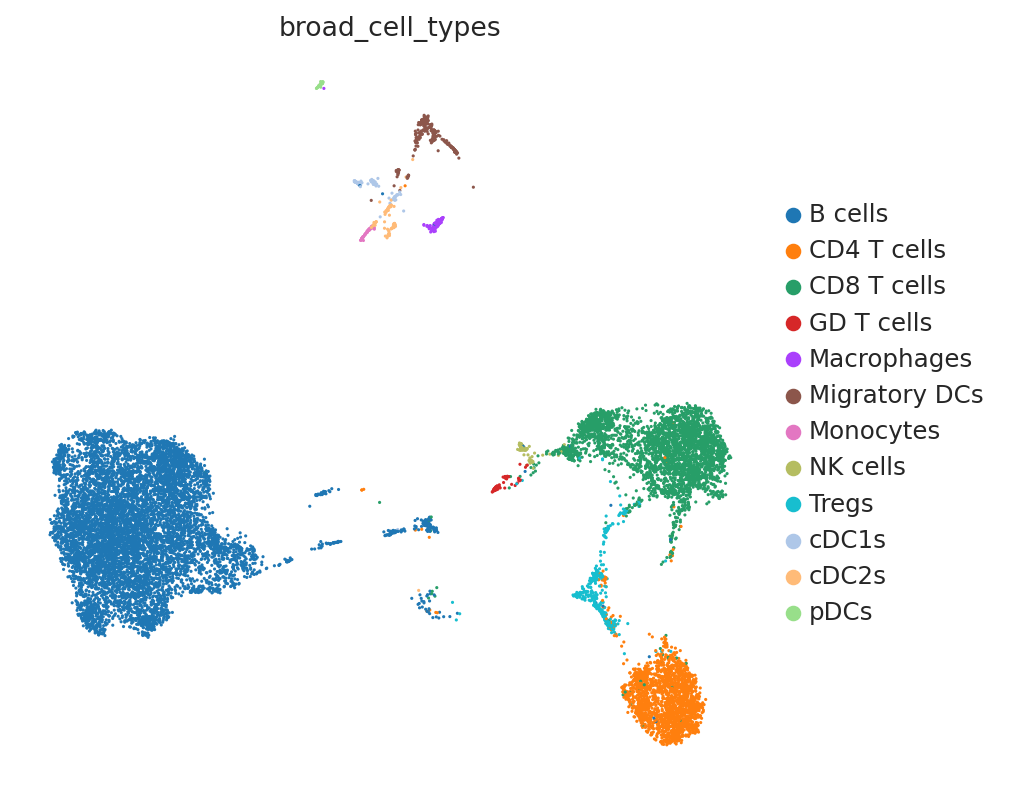

In [8]:
sc.pl.umap(sc_adata, color="broad_cell_types")

In [9]:
# Retain genes detected in at least 10 cells across the dataset
G = 2000
sc.pp.filter_genes(sc_adata, min_counts=10)

sc_adata.layers["counts"] = sc_adata.X.copy()  # preserve raw counts before normalization

# Select highly variable genes for model training (seurat_v3 uses raw counts)
sc.pp.highly_variable_genes(
    sc_adata, n_top_genes=G, subset=True, layer="counts", flavor="seurat_v3"
)

sc.pp.normalize_total(sc_adata, target_sum=10e4)
sc.pp.log1p(sc_adata)
sc_adata.raw = sc_adata  # store normalized data for plotting

### Spatial data

We load the Visium spatial dataset. DestVI requires both datasets to share the same gene set, so we will intersect the variable genes after loading. Raw counts are preserved in a dedicated `counts` layer (DestVI always operates on raw counts internally).

In [10]:
st_adata.layers["counts"] = st_adata.X.copy()  # raw counts for DestVI
st_adata.obsm["spatial"] = st_adata.obsm["location"]  # rename to standard key

# Normalize and log-transform for visualization (raw counts are preserved in the layer)
sc.pp.normalize_total(st_adata, target_sum=10e4)
sc.pp.log1p(st_adata)
st_adata.raw = st_adata

In [11]:
# Restrict both datasets to their shared gene set — a prerequisite for DestVI
intersect = np.intersect1d(sc_adata.var_names, st_adata.var_names)
st_adata = st_adata[:, intersect].copy()
sc_adata = sc_adata[:, intersect].copy()
G = len(intersect)
print(f"Shared genes: {G}")

Shared genes: 1888


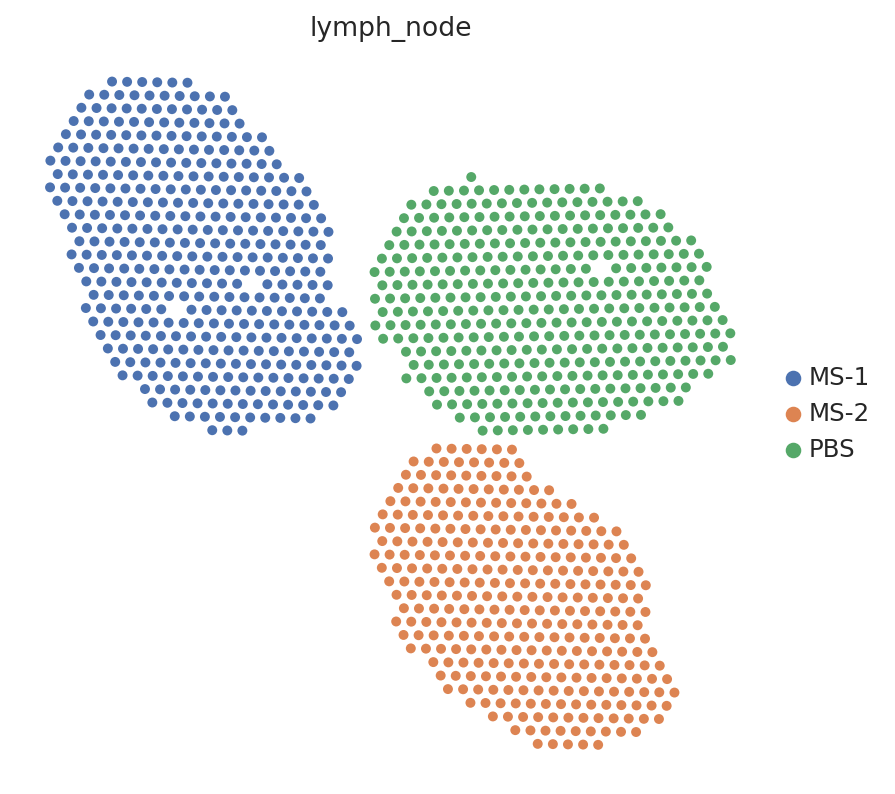

In [12]:
sc.pl.embedding(st_adata, basis="spatial", color="lymph_node", s=80)

## Step 1 — Fit the scLVM (CondSCVI)

CondSCVI is a **cell-type-conditional Variational Autoencoder** that learns a low-dimensional latent space for each cell type separately. The latent coordinates (gamma) capture continuous within-cell-type variation (e.g., an interferon-stimulated sub-state of B cells) that DestVI will later map back onto the spatial data.

`CondSCVI.setup_anndata` registers the raw counts layer, the broad cell-type labels (used as the conditioning variable during training), and the fine-grained labels (used to define `vamp_prior_p` clusters that shape the prior distribution in the spatial model).

In [13]:
sc_adata.obs.head()

,n_genes,cell_types,batch,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,pred_cell_types,doublet_scores,doublet_predictions,...,louvain_sub_0.1,louvain_sub_0.2,louvain_sub_0.3,louvain_sub,louvain_sub_1,louvain_sub_2,louvain_sub_3,SCANVI_pred_cell_types,SCVI_pred_cell_types,broad_cell_types
AAACCCAAGCAGAAAG-1-0,1505,Tregs,0,1505,5862.0,307.0,5.237121,Tregs,0.090909,0.0,...,6,6,6,Tregs,Tregs,"6,1","6,1",Tregs,Tregs,Tregs
AAACCCAAGGTCACAG-1-0,1883,Mature B cells,0,1883,6673.0,346.0,5.185074,Mature B,0.116751,0.0,...,0,0,0,"B cells,0","B cells,0",0,0,Cycling B/T cells,Mature B,B cells
AAACCCACATCGTTCC-1-0,2080,CD8 T cells,0,2080,7764.0,438.0,5.641422,CD122+ CD8 T,0.041626,0.0,...,1,"1-3,0",1,CD8 T cells,CD8 T cells,"1-3,0","1-3,0",CD8 T,CD8 T,CD8 T cells
AAACCCAGTCGTCTCT-1-0,1647,Cycling B/T cells,0,1647,4619.0,265.0,5.737173,Mature B,0.098634,0.0,...,5,5,5,"B cells,7","B cells,7",5,5,Ifit3-high B,Mature B,B cells
AAACCCAGTGTAAACA-1-0,1857,Mature B cells,0,1857,5965.0,339.0,5.683152,Mature B,0.153374,0.0,...,0,0,0,"B cells,3","B cells,3",0,0,B-macrophage doublets,Mature B,B cells


In [14]:
CondSCVI.setup_anndata(
    sc_adata,
    layer="counts",  # raw counts
    labels_key="broad_cell_types",  # broad cell-type labels (conditioning variable)
    fine_labels_key="cell_types",  # fine labels (used for vamp prior clustering)
    batch_key="batch",
)

We train CondSCVI for 100 epochs without cell-type reweighting (`weight_obs=False`), which is appropriate when cell types are roughly balanced. We use a **mixture-of-Gaussians prior** (`prior='mog'`, `num_classes_mog=10`) to better capture multi-modal distributions within each cell type.

Training takes ~5 minutes on a GPU.

In [15]:
sc_model = CondSCVI(
    sc_adata,
    weight_obs=False,  # no cell-type reweighting (balanced dataset)
    prior="mog",  # mixture-of-Gaussians prior for multi-modal cell states
    num_classes_mog=10,  # 10 mixture components per cell type
)
sc_model.view_anndata_setup()

Anndata setup with scvi-tools version 1.4.3.

Setup via `CondSCVI.setup_anndata` with arguments:

{
│   'batch_key': 'batch',
│   'labels_key': 'broad_cell_types',
│   'fine_labels_key': 'cell_types',
│   'layer': 'counts',
│   'unlabeled_category': 'unlabeled',
│   'size_factor_key': None
}

     Summary Statistics     
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Summary Stat Key ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│     n_batch      │   4   │
│     n_cells      │ 14989 │
│  n_fine_labels   │  16   │
│     n_labels     │  12   │
│      n_vars      │ 1888  │
└──────────────────┴───────┘

                  Data Registry                  
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃      scvi-tools Location       ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      X       │     adata.layers['counts']     │
│    batch     │    adata.obs['_scvi_batch']    │
│ fine_labels  │ adata.obs['_scvi_fine_labels'] │
│    labels    │   adata.obs['_scvi_labels']    │
└──────────────┴────────────────────────────────┘

                         labels State Registry                         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃        Source Location        ┃  Categories   ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['broad_cell_types'] │    B cells    │          0          │
│                               │  CD4 T cells  │          1          │
│                               │  CD8 T cells  │          2          │
│                               │  GD T cells   │          3          │
│                               │  Macrophages  │          4          │
│                               │ Migratory DCs │          5          │
│                               │   Monocytes   │          6          │
│                               │   NK cells    │          7          │
│                               │     Tregs     │          8          │
│                               │     cDC1s     │          9          │
│                               │     cDC2s     │         10          │
│                               │     pDCs      │         11          │
└───────────────────────────────┴───────────────┴─────────────────────┘

                  batch State Registry                   
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃  Source Location   ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['batch'] │     0      │          0          │
│                    │     1      │          1          │
│                    │     2      │          2          │
│                    │     3      │          3          │
└────────────────────┴────────────┴─────────────────────┘

                       fine_labels State Registry                       
┏━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃     Source Location     ┃      Categories      ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['cell_types'] │     CD4 T cells      │          0          │
│                         │     CD8 T cells      │          1          │
│                         │ Cxcl9-high monocytes │          2          │
│                         │  Cycling B/T cells   │          3          │
│                         │      GD T cells      │          4          │
│                         │  Ifit3-high B cells  │          5          │
│                         │  Ly6-high monocytes  │          6          │
│                         │     Macrophages      │          7          │
│                         │    Mature B cells    │          8          │
│                         │    Migratory DCs     │          9          │
│                         │       NK cells       │         10          │
│                         │        Tregs         │         11          │
│                         │        cDC1s         │         12          │
│                         │        cDC2s         │         13          │
│                         │         pDCs         │         14          │
│                         │      unlabeled       │         15          │
└─────────────────────────┴──────────────────────┴─────────────────────┘

In [16]:
sc_model.train(max_epochs=100)

INFO: Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
2026-07-05 10:07:42 | [INFO] Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
INFO: GPU available: True (cuda), used: True
2026-07-05 10:07:42 | [INFO] GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
2026-07-05 10:07:42 | [INFO] TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and ar

Training:   0%|          | 0/100 [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=100` reached.
2026-07-05 10:08:48 | [INFO] `Trainer.fit` stopped: `max_epochs=100` reached.


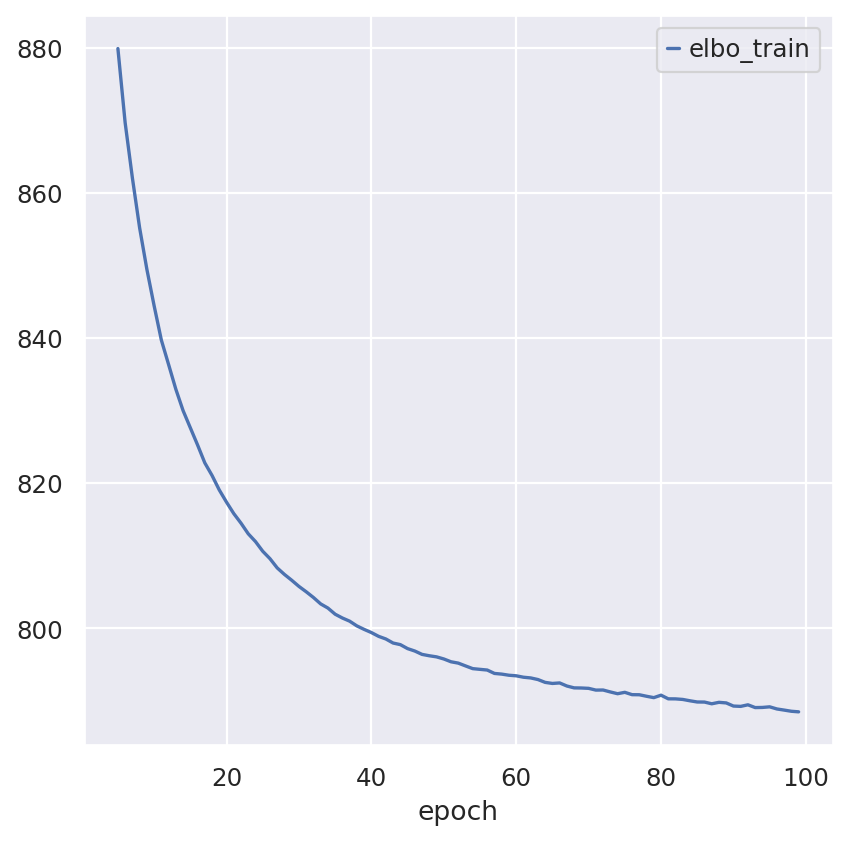

In [17]:
sc_model.history["elbo_train"].iloc[5:].plot()
plt.show()

The training loss converges quickly. Reducing `max_epochs` below 200 degrades the quality of the learned gamma representations and is not recommended.

## Step 2 — Train the stLVM (DestVI)

DestVI transfers the decoder network learned by CondSCVI to the spatial domain. For each spot, it infers:

1. **Cell-type proportions** — what fraction of the spot's RNA comes from each cell type.
2. **Cell-type-specific gamma values** — where in the CondSCVI latent space the cells of each type in that spot fall.

`DestVI.from_rna_model` constructs the spatial model directly from the trained CondSCVI model. The `smoothed` layer (a spatially smoothed version of the raw counts, constructed via a 5-NN graph) is used internally to improve proportion estimation in low-count spots.

In [18]:
# Remove spots with fewer than 10 total counts (empty or near-empty capture areas)
st_adata = st_adata[st_adata.layers["counts"].sum(1) > 10].copy()
st_adata.obs["batch"] = "spatial"  # distinguish from scRNA-seq batches in the registry


def spatial_nn_gex_smth(stadata, n_neighs):
    # Spatially smooth raw counts by averaging over k nearest neighbors.
    rsc.pp.neighbors(stadata, n_neighs, use_rep="spatial", key_added="Xspatial")
    stadata.obsp["Xspatial_connectivities"] = stadata.obsp["Xspatial_connectivities"].ceil()
    stadata.obsp["Xspatial_connectivities"].setdiag(1)
    return stadata.obsp["Xspatial_connectivities"].dot(stadata.layers["counts"])


# Smoothed counts improve proportion estimation in low-count spots
st_adata.layers["smoothed"] = spatial_nn_gex_smth(st_adata, n_neighs=5)

Key hyperparameters and their effects:

- **`vamp_prior_p`** (from `sc_model`): number of k-means clusters used to shape the variational prior per cell type. More clusters → more gradual gamma transitions across tissue.
- **`l1_sparsity`**: encourages sparser cell-type proportion estimates. Higher values → fewer non-zero cell types per spot.
- **`beta_weighting_prior`**: controls anchoring strength to the scRNA-seq prior. Adjust if library preparation differed substantially between assays.
- **`add_celltypes=2`**: adds catch-all cell-type slots to absorb expression patterns not in the reference.

Training takes ~5 minutes on a GPU.

In [19]:
st_model = DestVI.from_rna_model(
    st_adata,
    sc_model,
    add_celltypes=2,
    n_latent_amortization=None,
    anndata_setup_kwargs={"smoothed_layer": "smoothed"},
)
st_model.view_anndata_setup()

Anndata setup with scvi-tools version 1.4.3.

Setup via `DestVI.setup_anndata` with arguments:

{'layer': 'counts', 'smoothed_layer': 'smoothed', 'batch_key': 'batch'}

     Summary Statistics     
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Summary Stat Key ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│     n_batch      │   5   │
│     n_cells      │ 1092  │
│      n_vars      │ 1888  │
│   n_x_smoothed   │ 1888  │
└──────────────────┴───────┘

               Data Registry               
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃   scvi-tools Location    ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      X       │  adata.layers['counts']  │
│    batch     │ adata.obs['_scvi_batch'] │
│    ind_x     │  adata.obs['_indices']   │
│  x_smoothed  │ adata.layers['smoothed'] │
└──────────────┴──────────────────────────┘

                  batch State Registry                   
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃  Source Location   ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['batch'] │     0      │          0          │
│                    │     1      │          1          │
│                    │     2      │          2          │
│                    │     3      │          3          │
│                    │  spatial   │          4          │
└────────────────────┴────────────┴─────────────────────┘

In [20]:
st_model.train(max_epochs=250)

INFO: Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
2026-07-05 10:08:48 | [INFO] Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
INFO: GPU available: True (cuda), used: True
2026-07-05 10:08:48 | [INFO] GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
2026-07-05 10:08:48 | [INFO] TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and ar

Training:   0%|          | 0/250 [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=250` reached.
2026-07-05 10:09:14 | [INFO] `Trainer.fit` stopped: `max_epochs=250` reached.


The training loss (ELBO) should decrease monotonically and plateau before `max_epochs`. We recommend at least 1,000 epochs for production runs; 250 is sufficient for this tutorial.

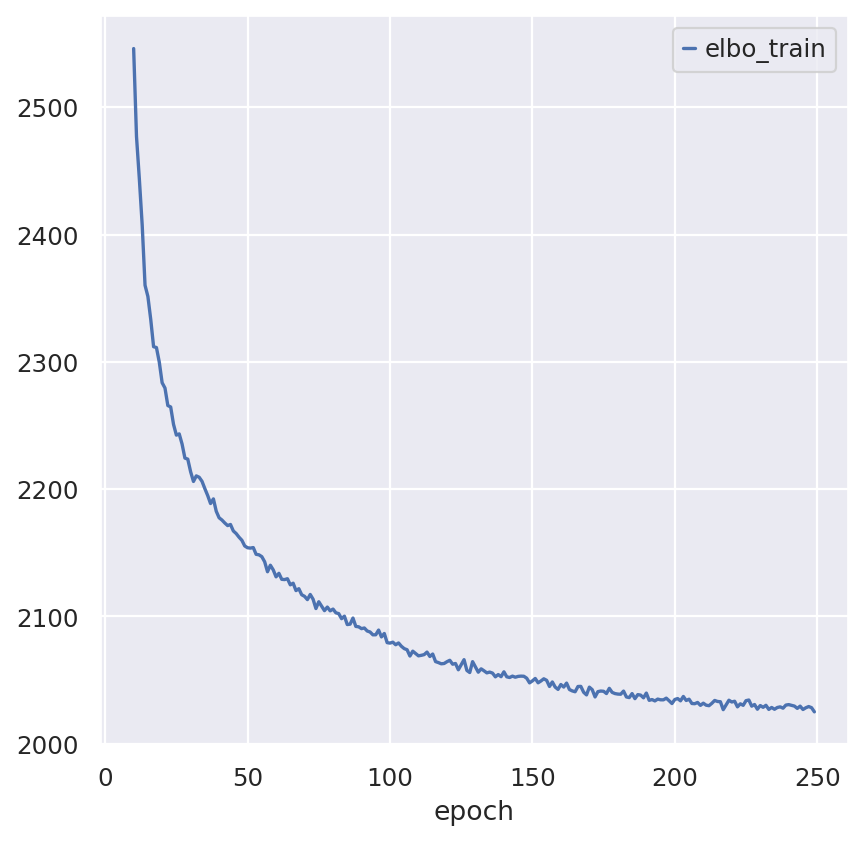

In [21]:
st_model.history["elbo_train"].iloc[10:].plot()
plt.show()

## Step 3 — Extract and visualize cell-type proportions

DestVI returns two types of output:

1. **Cell-type proportions** (broad resolution): a spot × cell-type matrix of non-negative values summing to 1.
2. **Gamma values** (fine resolution): a 5-dimensional latent vector per cell type per spot, capturing within-cell-type state variation.

### Cell-type proportions

`get_proportions()` extracts the estimated cell-type proportions for every spot. We display a subset of cell types (`B cells`, `CD8 T cells`, `Monocytes`) to illustrate the expected spatial compartmentalization of the lymph node.

In [22]:
# Extract estimated cell-type proportions (spots x cell types, rows sum to 1)
st_adata.obsm["proportions"] = st_model.get_proportions()

In [23]:
st_adata.obsm["proportions"].head(5)

,B cells,CD4 T cells,CD8 T cells,GD T cells,Macrophages,Migratory DCs,Monocytes,NK cells,Tregs,cDC1s,cDC2s,pDCs
AAACCGGGTAGGTACC-1-0,0.718451,0.010427,0.073341,0.001814,0.057443,0.022810,0.043873,0.001912,0.028208,0.036480,0.001113,0.004128
AAACCTCATGAAGTTG-1-0,0.680159,0.027523,0.067728,0.005409,0.036853,0.044871,0.032473,0.001420,0.066462,0.034298,0.000988,0.001816
AAAGACTGGGCGCTTT-1-0,0.644495,0.033299,0.108767,0.002375,0.047263,0.053777,0.017253,0.003161,0.042282,0.044455,0.000887,0.001987
AAAGGGCAGCTTGAAT-1-0,0.124643,0.073489,0.421470,0.008409,0.035872,0.149055,0.031040,0.008447,0.094857,0.050393,0.000785,0.001541
AAAGTCGACCCTCAGT-1-0,0.865737,0.015224,0.011635,0.002319,0.053940,0.009655,0.013101,0.000800,0.004684,0.021321,0.000309,0.001275


In [24]:
# Clip at the 99th percentile to reduce the visual impact of extreme outlier spots
ct_list = ["B cells", "CD8 T cells", "Monocytes"]
for ct in ct_list:
    data = st_adata.obsm["proportions"][ct].values
    st_adata.obs[ct] = np.clip(data, 0, np.quantile(data, 0.99))

... storing 'batch' as categorical


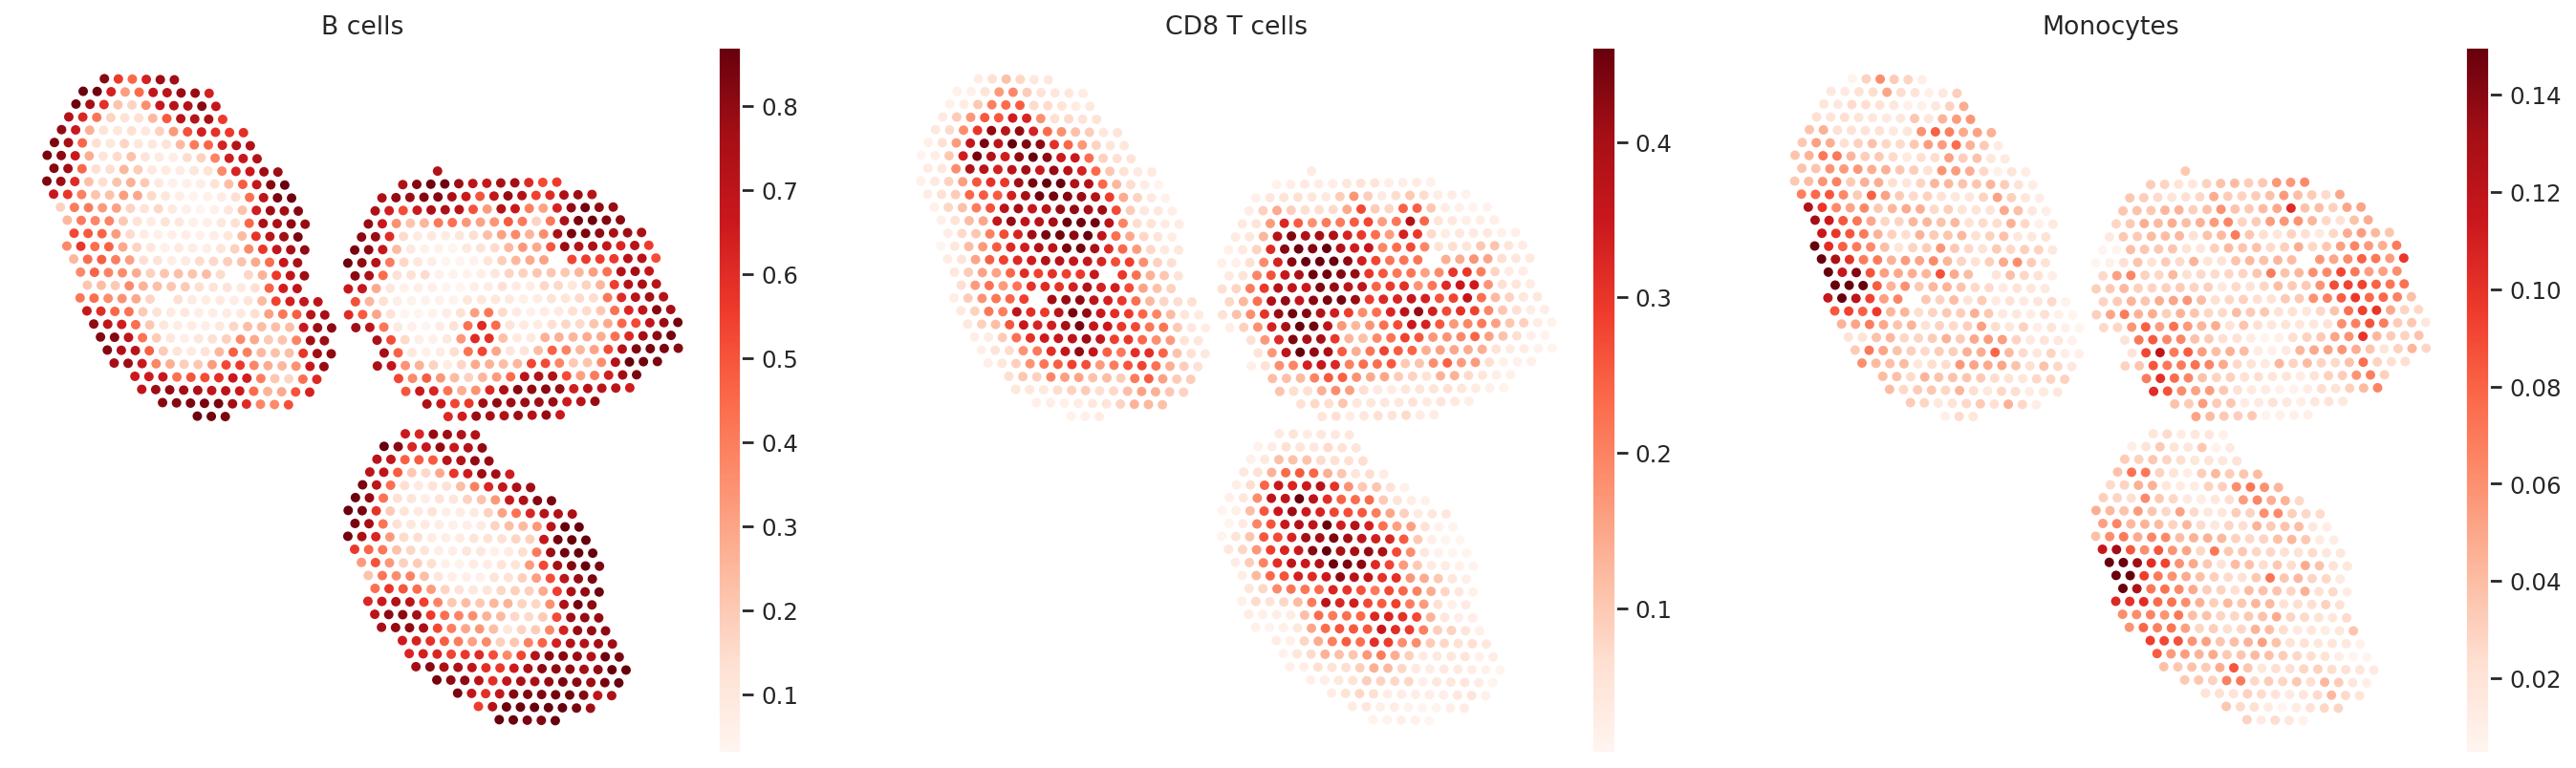

In [25]:
sc.pl.embedding(st_adata, basis="spatial", color=ct_list, cmap="Reds", s=80)

Because stLVM proportion estimates are never exactly zero, follow-up analyses that use cell-type-specific gene expression must first threshold the proportions to distinguish spots where a cell type is genuinely present from spots where its estimated proportion is residual noise.

`destvi_utils.automatic_proportion_threshold` determines a data-driven cutoff for each cell type. This utility is part of the `destvi_utils` companion package (installable from GitHub; see the top of this notebook).

100%|██████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 526.13it/s]


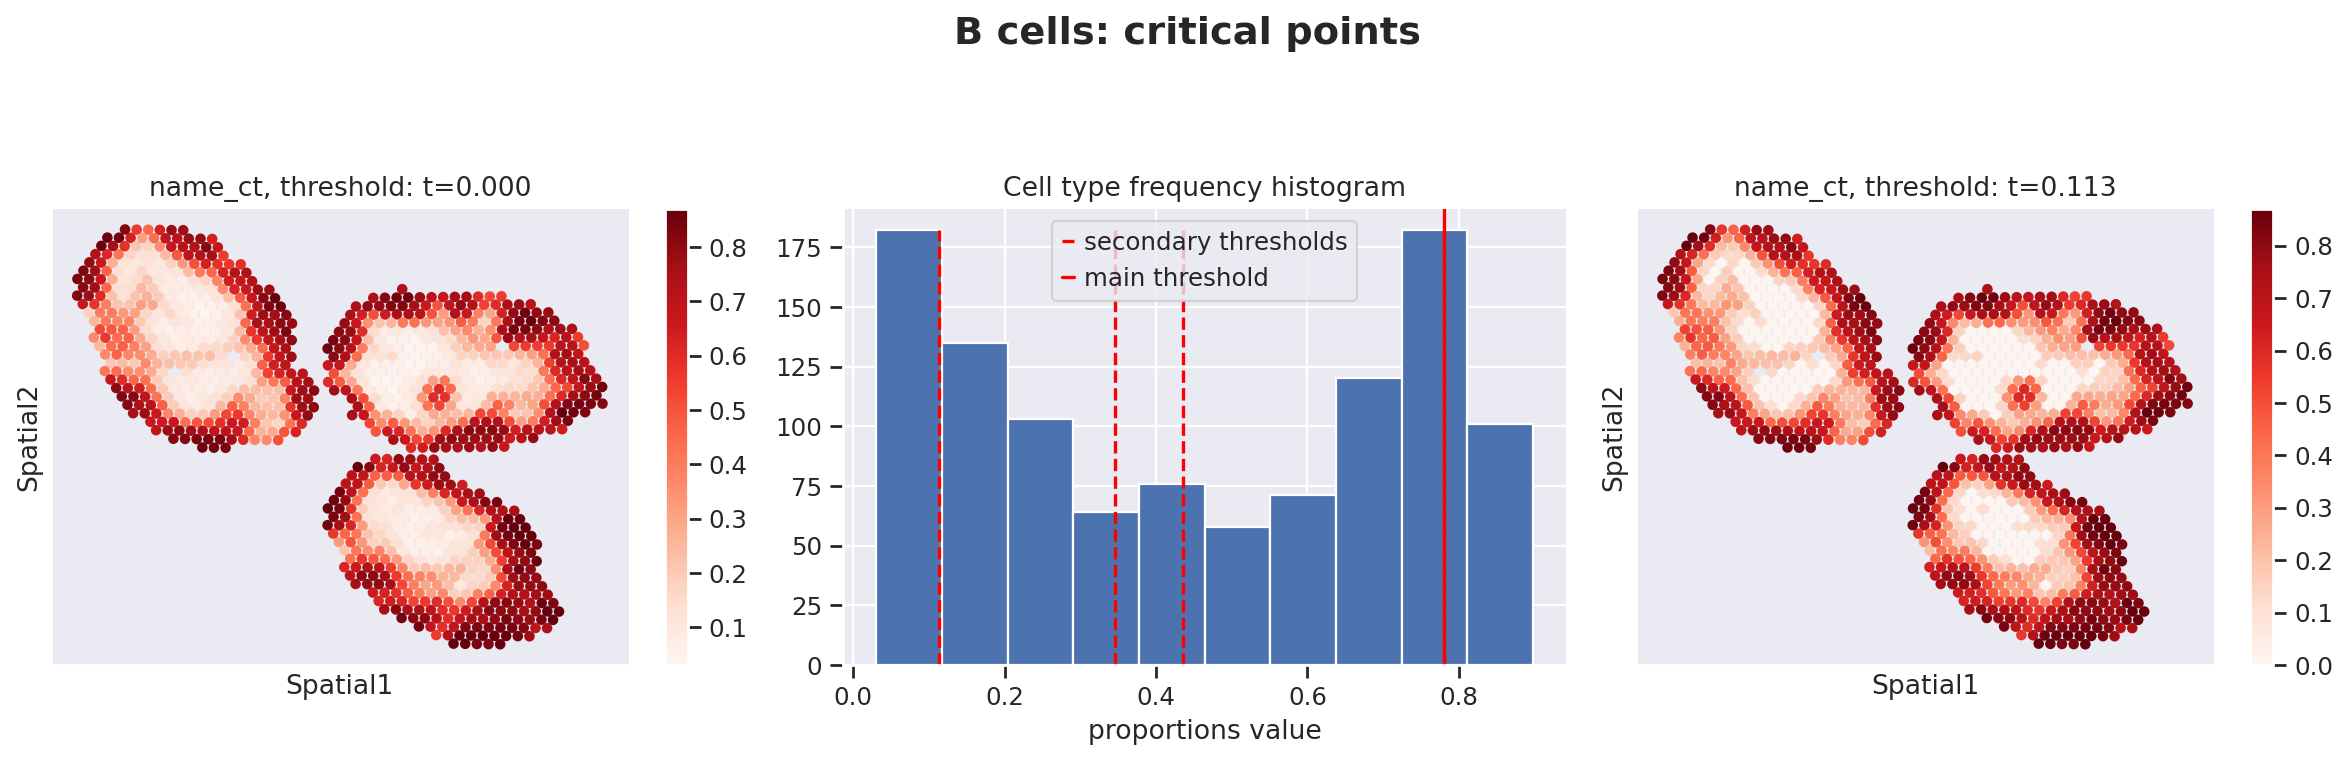

100%|████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 52402.60it/s]


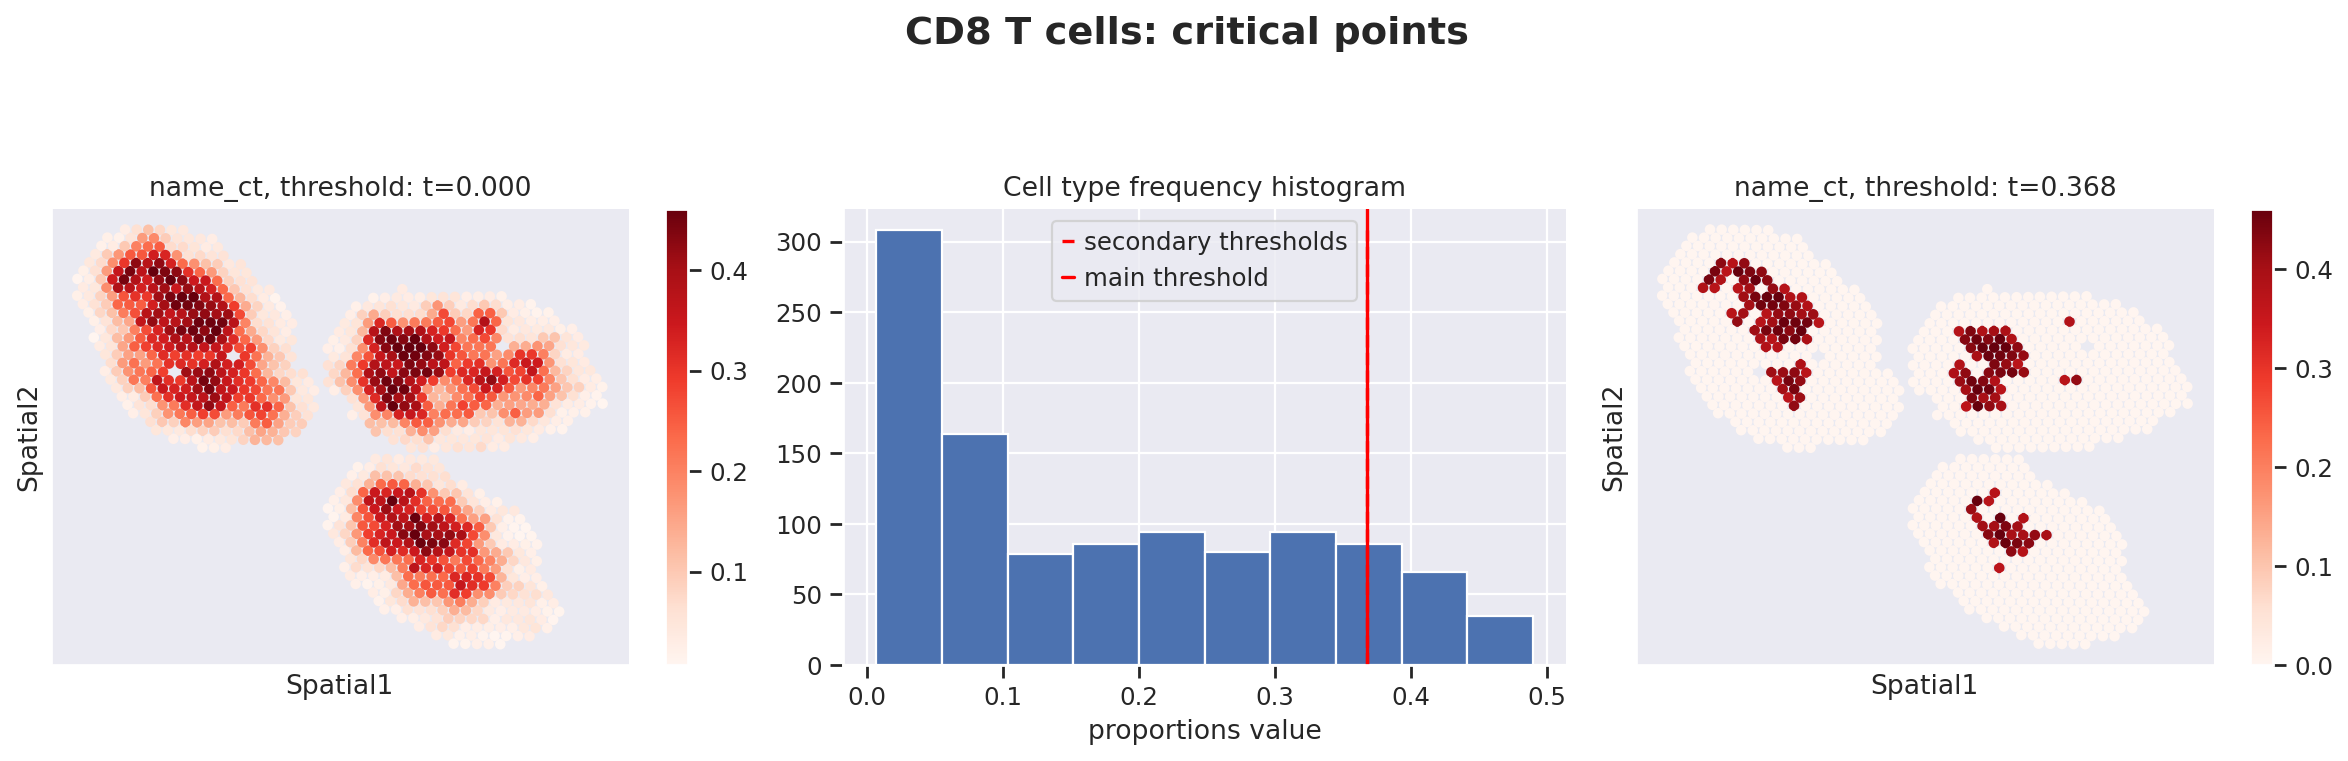

100%|████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 45874.48it/s]


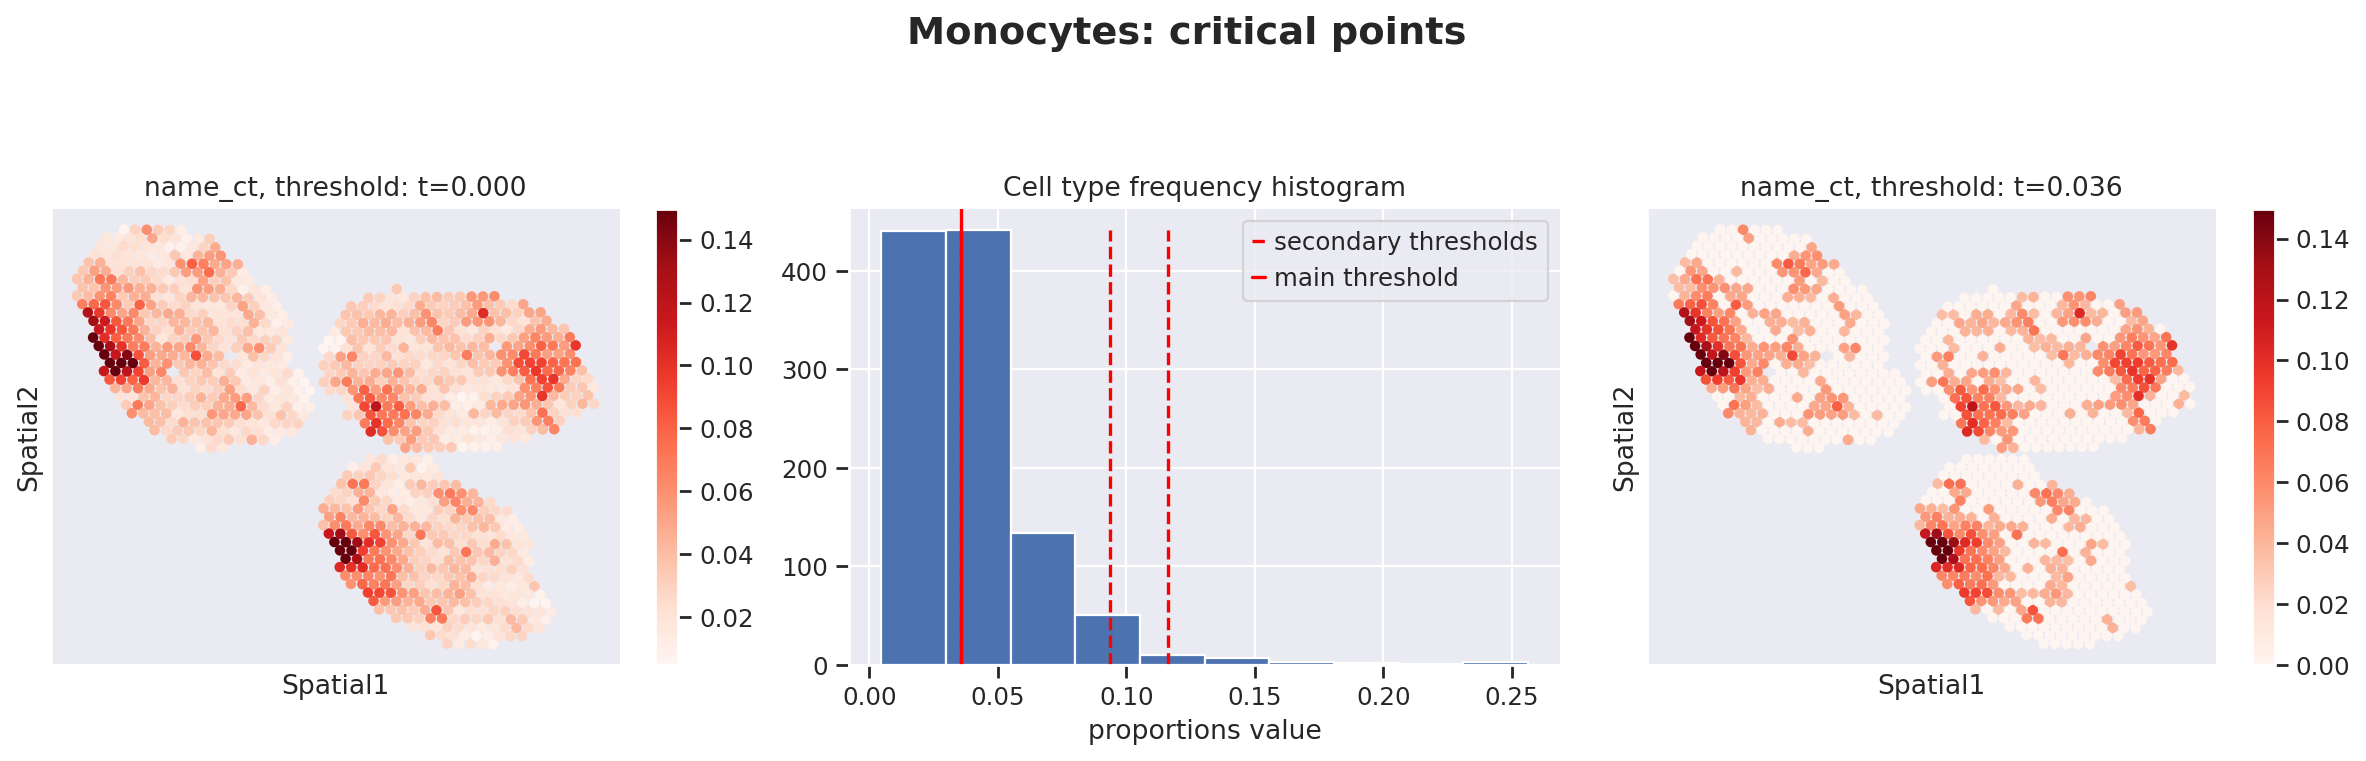

In [26]:
ct_thresholds = destvi_utils.automatic_proportion_threshold(
    st_adata, ct_list=ct_list, kind_threshold="secondary"
)

The results confirm the expected spatial compartmentalization: B cells in the follicle zone, CD8 T cells in T-cell zones, and condition-dependent monocyte distribution (refer to the DestVI paper for full details).

## Step 4 — Explore intra-cell-type variation (gamma values)

Beyond proportions, DestVI provides **gamma** — a low-dimensional (5D) latent vector per cell type per spot that captures continuous within-cell-type variation. A spot enriched in IFN-stimulated B cells will have different gamma values for the "B cells" cell type than a spot enriched in resting B cells, even if the overall B-cell proportion is similar.

In [27]:
# Store 5D gamma latent vectors for every cell type as obsm entries
# gamma[i, j] = latent coordinate j for cell type i in each spot
for ct, g in st_model.get_gamma().items():
    st_adata.obsm[f"{ct}_gamma"] = g

In [28]:
st_adata.obsm["B cells_gamma"].head(5)

,0,1,2,3,4
AAACCGGGTAGGTACC-1-0,-0.428617,0.489513,0.066342,-0.638228,0.903473
AAACCTCATGAAGTTG-1-0,-0.516862,0.223180,0.439018,-0.951158,1.465745
AAAGACTGGGCGCTTT-1-0,0.400772,-0.067410,0.619300,-0.534040,0.605672
AAAGGGCAGCTTGAAT-1-0,-0.659599,0.494461,0.334034,-0.289904,0.586542
AAAGTCGACCCTCAGT-1-0,-0.491982,0.080405,0.226639,-0.693034,1.481275


`destvi_utils.explore_gamma_space` provides an automated pipeline to interpret the gamma space for each cell type:

1. **Select** spots above the proportion threshold for each cell type.
2. **Compute** spatially-weighted PCA on the gamma values of selected spots to find the axes of spatial variation.
3. **Color** each spot and each reference single cell by their coordinate in the first two sPCs.
4. **Plot** (A) colors in tissue coordinates, (B) colors in sPC space for spots, (C) colors in sPC space for reference single cells.
5. **Annotate** enriched genes along each sPC axis using EnrichR.

For B cells, the first sPC corresponds to an interferon response (Ifit1/3, Isg15, Oas3) concentrated in the interfollicular area of mycobacteria-exposed lymph nodes.

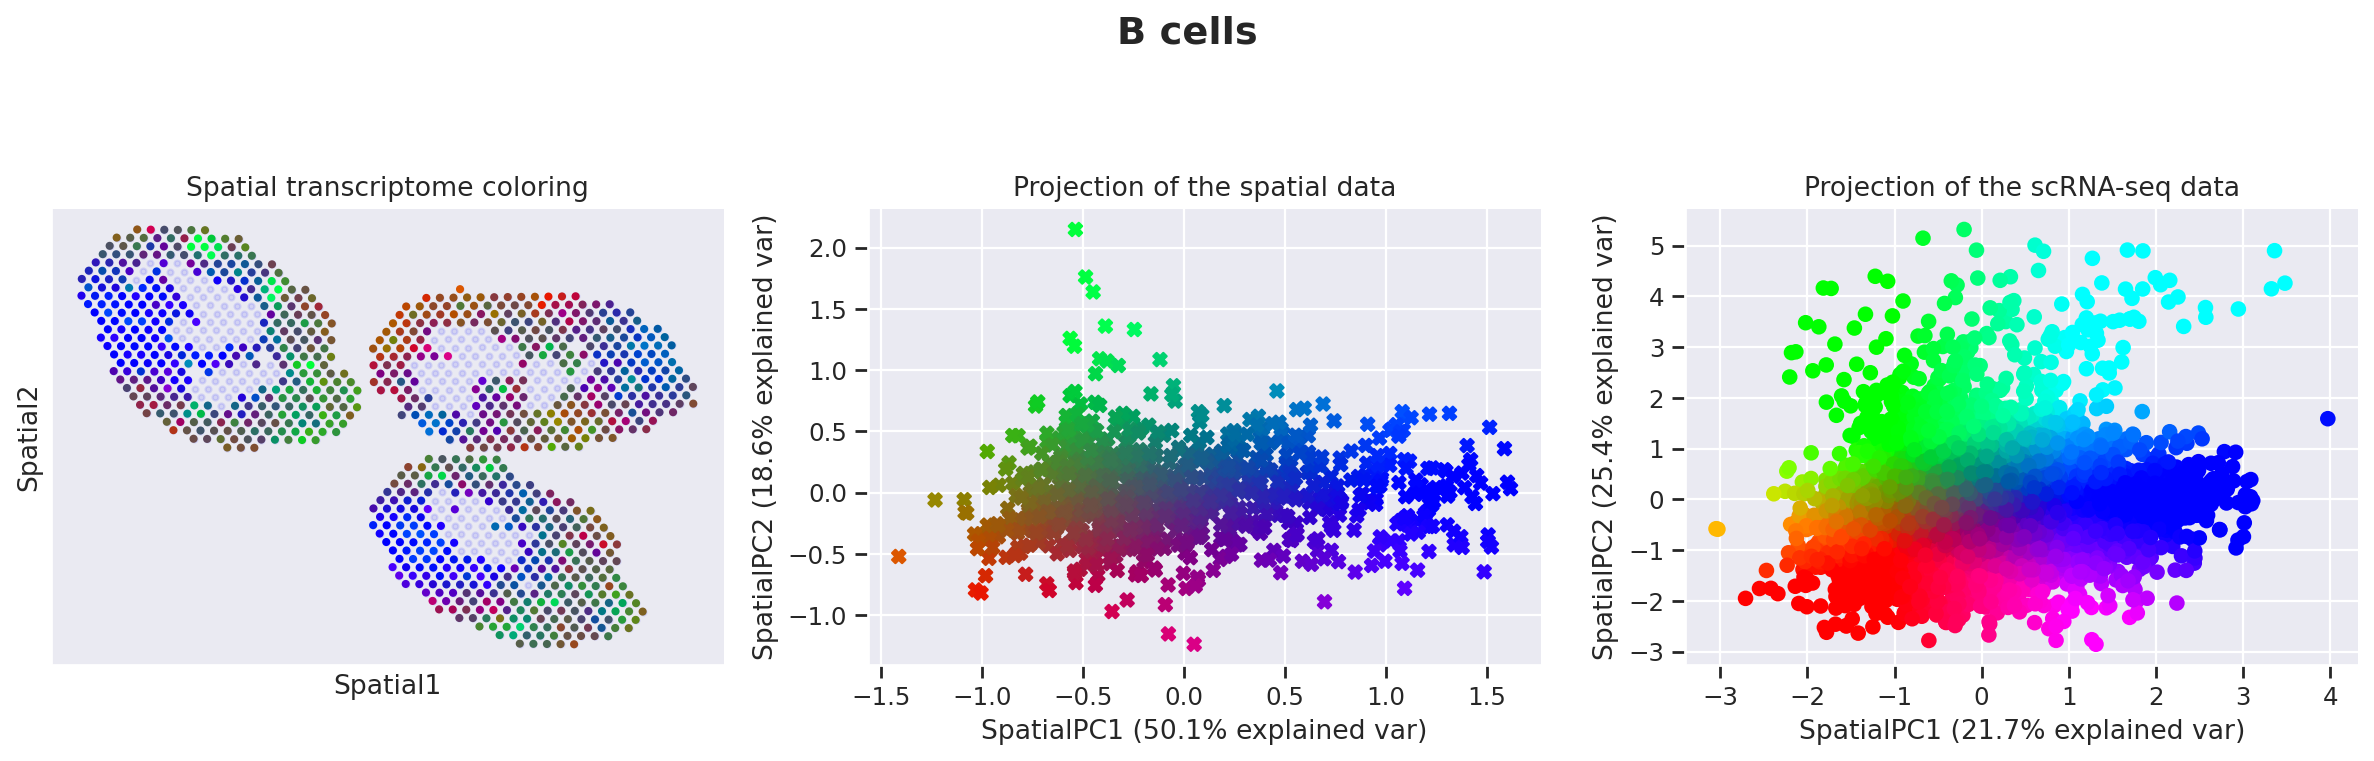

Genes associated with SpatialPC1

Positively

---------------------------------------------------------------------------------------

Ifit3, Stat1, Rtp4, Slfn5, Zbp1, Irf7, Trim30a, Usp18, Ifi47, Ifit3b, Parp14, Ifit1, Ifit2, Oasl2, Isg15, Ifi27l2a,
Rnf213, Rsad2, Igtp, Gbp7, Serpina3g, Bst2, Phf11b, Oas3, Eif2ak2, Gbp4, Pkib, Isg20, Herc6, Ly6a, Lgals3bp, Cmpk2,
Ifitm3, Irf1, Trafd1, Malat1, Cybb, Socs1, Ms4a4c, Sdc3, Plac8, Ms4a4b, Psmb9, Serpina3f, Gbp2, Epsti1, Mpeg1, 
Phf11a, Tcf4, B2m

---------------------------------------------------------------------------------------

...

Negatively

---------------------------------------------------------------------------------------

Cd79a, Cd74, H2-Eb1, H2-Aa, H2-Ab1, Ly6d, Ighm, Fth1, Ms4a1, Iglc3, Iglc2, Vpreb3, Igkc, Mef2c, Fcer2a, Malat1, 
Rnase6, Napsa, Ctsh, Fcmr, Fcrla, Mzb1, Crip1, Chchd10, Itm2b, Serpinb1a, Hspa1b, Lsp1, Tmsb4x, Id3, Ly86, Pxdc1, 
Bcl11a, Fcgrt, Cst3, Rplp1, Unc93b1, Rpsa, Capg, Cd38, Icosl, Hist1h1c, Srgn, Jun, S100a10, Cd81, Hexb, Pglyrp1, 
Ciita, Tspo

---------------------------------------------------------------------------------------

Antigen-activated B-cell receptor generation of second messengers*, Immune system*, Innate immune system*, 
Signaling by the B cell receptor (BCR)*, Toll receptor cascades*, Adaptive immune system*, Immunoregulatory 
interactions between a lymphoid and a non-lymphoid cell*, Complement cascade, Antigen processing and presentation, 
TSH regulation of gene expression

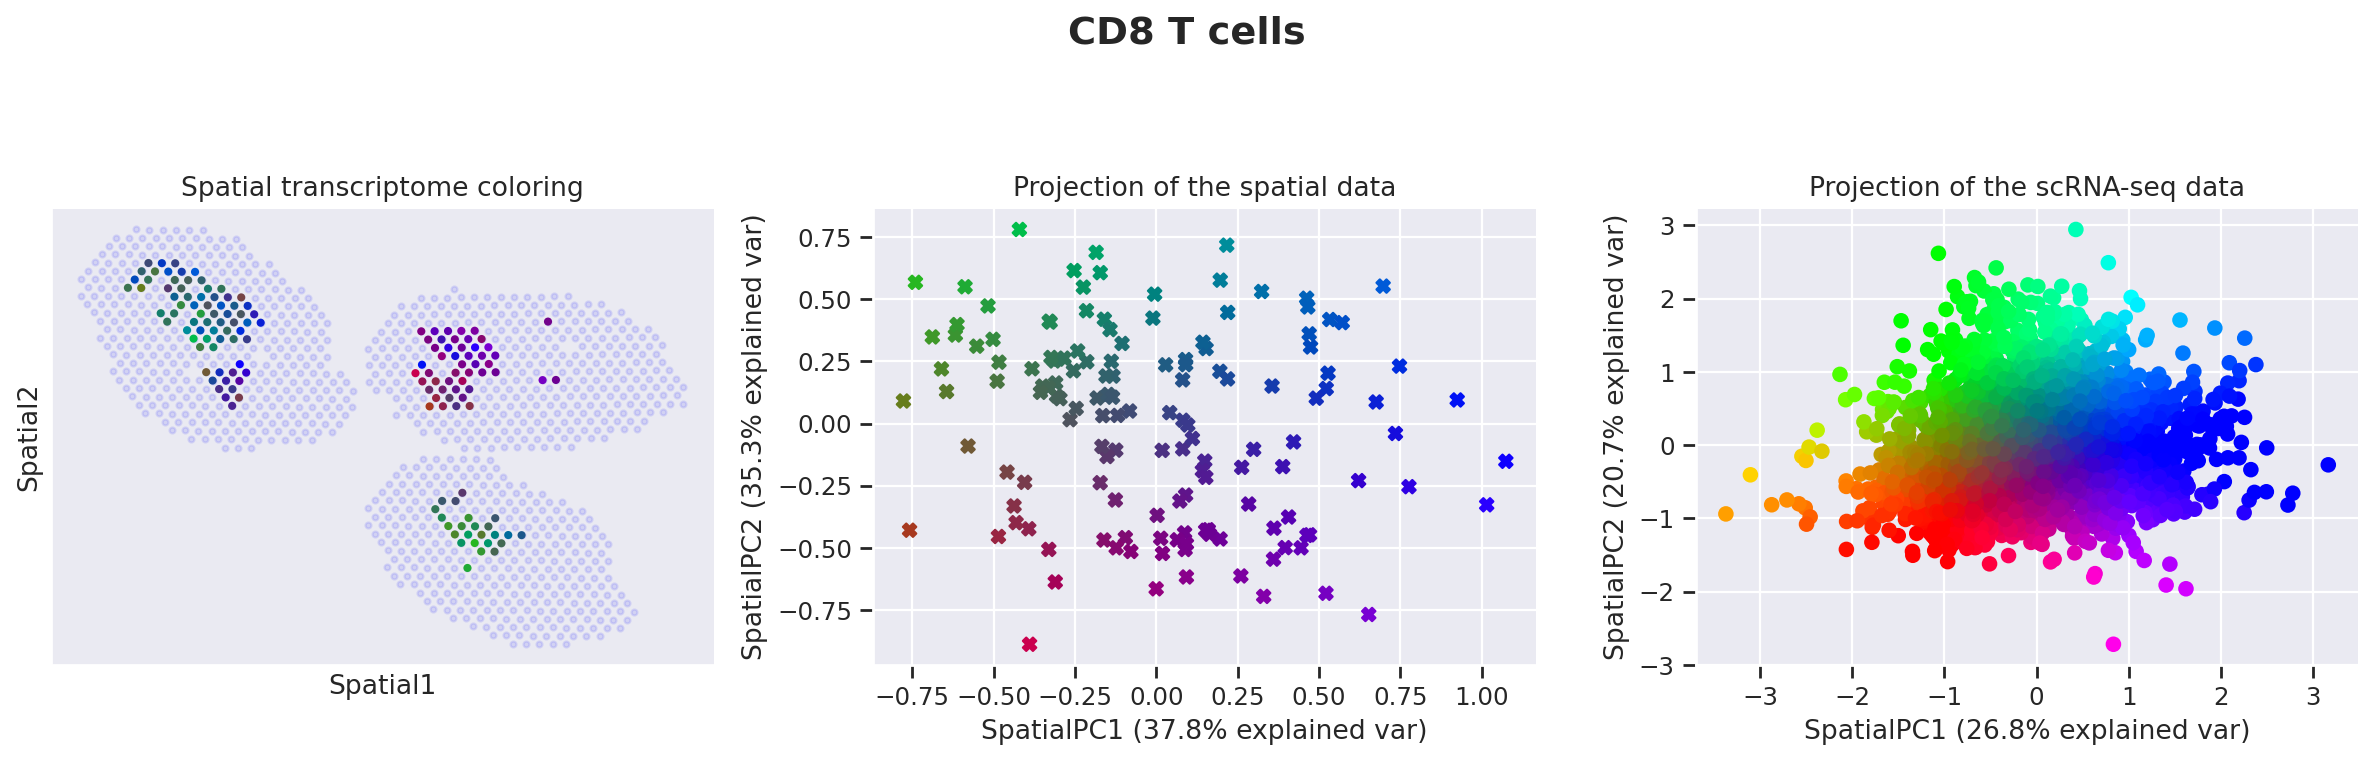

Genes associated with SpatialPC1

Positively

---------------------------------------------------------------------------------------

Rgcc, Ccr9, Cd8b1, Ramp1, Cd3g, Npc2, Cd8a, Itgae, Igfbp4, Ppia, Lef1, Actn2, Cd3e, Trbc2, Actb, Lat, Cd3d, Trac, 
Inpp4b, Actn1, Cd226, Plekho1, Timp2, Sox4, Dtx1, Ddit4, Tmsb4x, Ifi27l2a, Gsn, Gpr68, Ptma, Tesc, Bcl11b, Rplp0, 
Tubb5, Lztfl1, Sh3bp1, Izumo1r, Thy1, Malat1, Rpl41, Itm2b, Lck, Trat1, Dapl1, Cyb5a, Cd247, Actg1, Auts2, Trib2

---------------------------------------------------------------------------------------

...

Negatively

---------------------------------------------------------------------------------------

Ccl5, Ctla2a, Cxcr3, Xcl1, Ly6c2, Hopx, Rps12, Rpsa, Rps2, Il2rb, Samd3, 1700025G04Rik, Cd44, Gzmm, Ahnak, Ifitm10,
Plek, H2afz, Npm1, Rplp0, Ctla2b, Ccr5, S100a6, Il18rap, Pglyrp1, Gpr183, Klra7, Ifngr1, Itgb1, Zyx, Klre1, Itm2a, 
Lrrk1, Hspa8, Dennd4a, Klrc2, Bcl2, Bbc3, Klrc1, Runx2, Rpl41, Slamf7, Npm3, Efhd2, Fasl, Anxa2, Ccl4, Il18r1, 
Sidt1, Myo1f

---------------------------------------------------------------------------------------

Interleukin-2 signaling pathway*, Selective expression of chemokine receptors during T-cell polarization*, 
Cytokine-cytokine receptor interaction*, T cell receptor regulation of apoptosis*, Binding of chemokines to 
chemokine receptors*, Gastrin pathway*, Interleukin-12/STAT4 pathway*, Cytoplasmic ribosomal proteins*, Influenza 
viral RNA transcription and replication*, Interleukin-12-mediated signaling events*

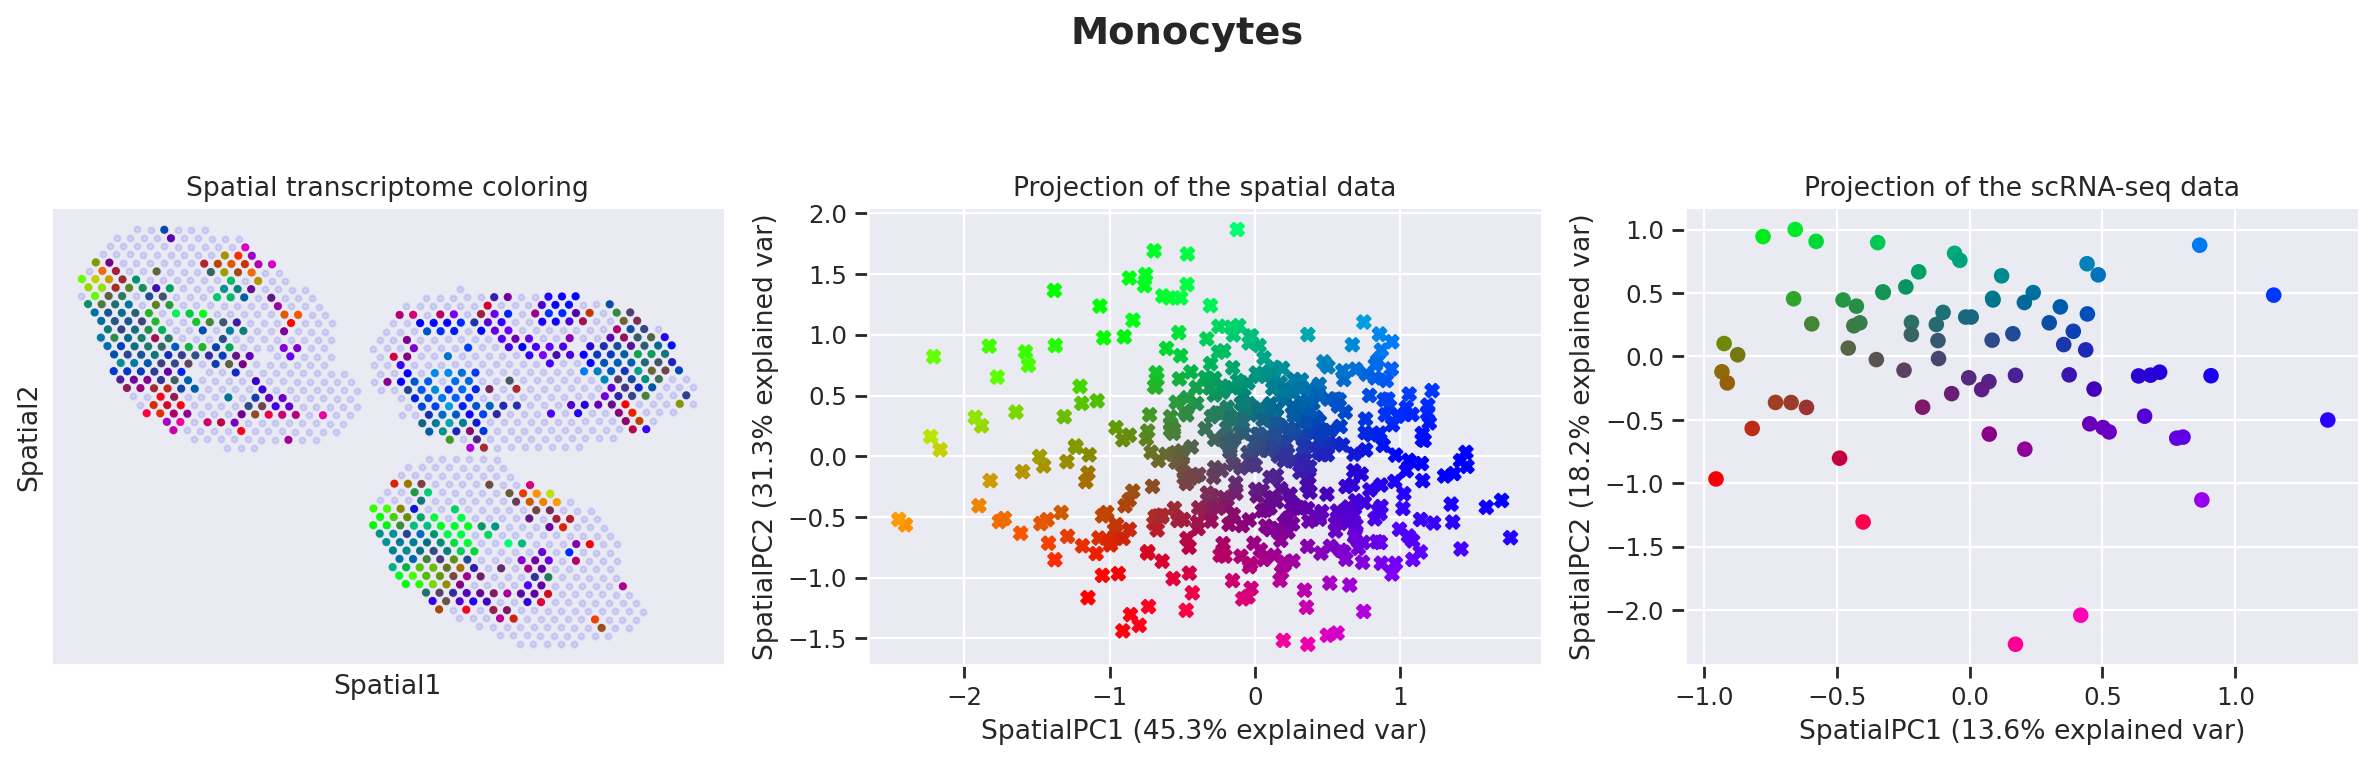

Genes associated with SpatialPC1

Positively

---------------------------------------------------------------------------------------

Ppia, Fabp5, Cd63, Tuba1a, Mif, Cdk4, Tuba1c, Sec61b, Tmsb4x, Tspan3, Itgax, Plxnc1, Hebp1, Eif4ebp1, Sema7a, 
Hnrnpll, Rgs10, Clec4n, Atpif1, Hspe1, Spint1, Dnase1l3, Pdia3, Ftl1, Itga8, S100a1, Cyb5a, Cfp, Hnrnpab, Basp1, 
Dbf4, Etfb, Rps2, Actn1, Abcd2, Atp5g1, Lsm2, Tfec, Tuba1b, Eif1ax, Sbf2, Kif2c, Hdgf, Ctsd, Uqcc2, Tgfbi, Fen1, 
Tarm1, Tubb2a, Nhp2

---------------------------------------------------------------------------------------

...

Negatively

---------------------------------------------------------------------------------------

Tmem26, Vcam1, Chst2, Cd38, Gfra2, Cd81, Prkar1b, Etv5, Ly75, Gpr157, Prg3, Rai14, Phyhd1, Sirpa, Actn1, Tspan4, 
Nuak1, Asb2, Mertk, Gpm6b, Fam20c, Inpp4b, Timp2, C1qc, Cacna1b, C1qa, C1qb, Ehf, Art2b, Pltp, Lrp8, Zc3h12c, 
Itga9, Cd63, Pdgfa, Kcnj10, Hebp1, Nrgn, Ifng, Il1r1, Chek1, 3830403N18Rik, Nav2, Jup, Nr1h3, Sucnr1, Sema6d, 
Itgb5, Tspan3, Tmem86a

---------------------------------------------------------------------------------------

Complement activation, classical pathway*, Systemic lupus erythematosus*, Arrhythmogenic right ventricular 
cardiomyopathy (ARVC)*, TGF-beta regulation of extracellular matrix*, Prion diseases*, Chagas disease*, Hemostasis 
pathway*, Malaria, Mechanism of gene regulation by peroxisome proliferators via PPAR-alpha, Interleukin-4 
regulation of apoptosis

In [29]:
destvi_utils.explore_gamma_space(st_model, sc_model, ct_list=ct_list, ct_thresholds=ct_thresholds)

The spatially-weighted PCA and its functional annotation provide a systematic way to formulate hypotheses about cell-state variation in spatial context — e.g., which sub-states are concentrated in which tissue compartments and how they change between conditions.

## Step 5 — Cell-type-specific differential expression (B cells)

We focus on B cells, which the gamma-space analysis flagged as spatially variable for interferon response genes. DestVI can **impute cell-type-specific gene expression** for any spot using `get_scale_for_ct`. This integrates proportion weights and gamma values to estimate what the B-cell-specific transcriptome looks like in each spot — even in spots that are not exclusively B cells.

Below, we visualize the spatial distribution of IFN-response genes (Ifit3, Ifit1, Isg15, etc.) restricted to spots with ≥20% B cells.

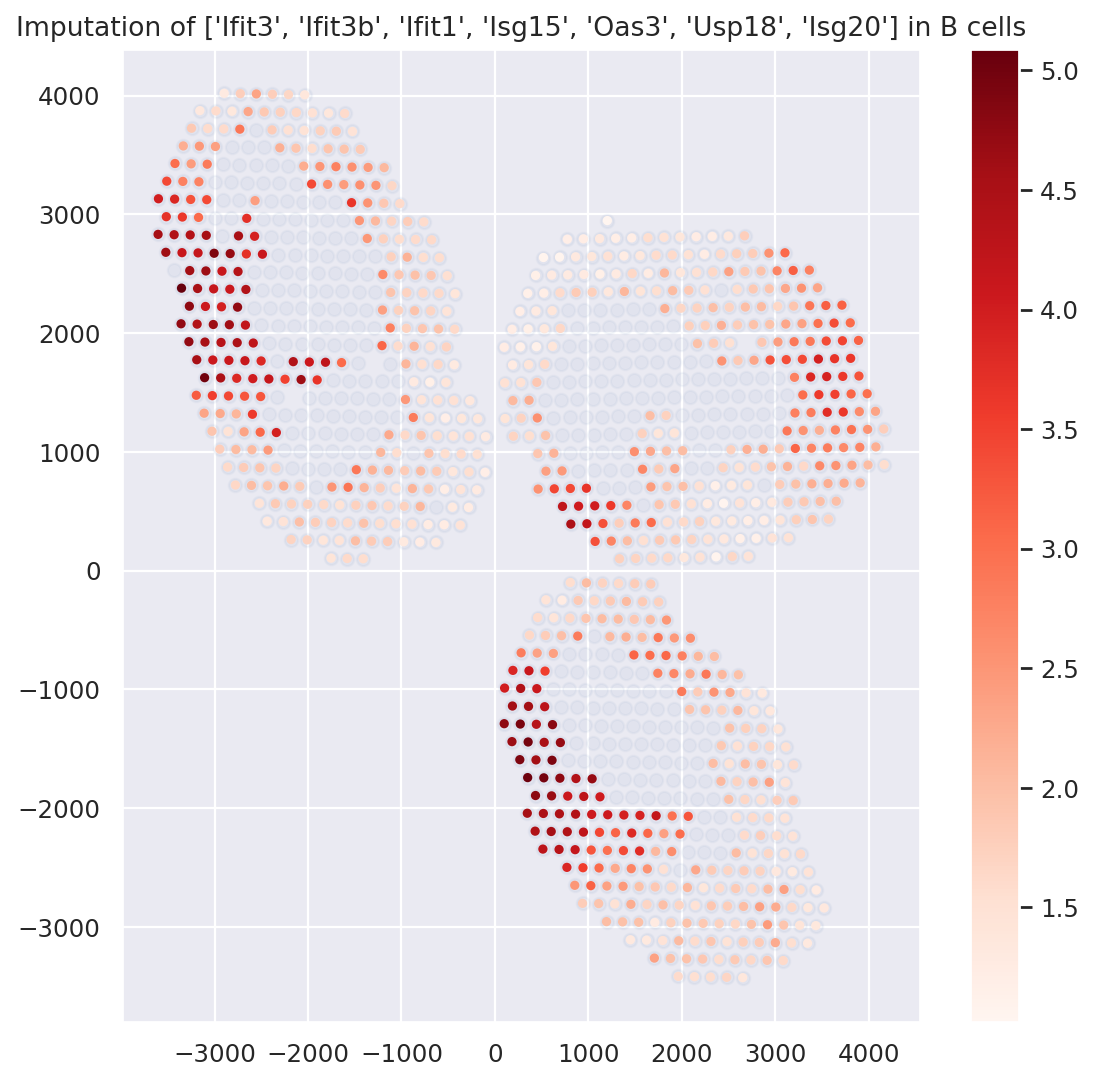

In [30]:
plt.figure(figsize=(8, 8))

ct_name = "B cells"
gene_name = ["Ifit3", "Ifit3b", "Ifit1", "Isg15", "Oas3", "Usp18", "Isg20"]

# Restrict to spots with at least 20% B cells to reduce imputation noise
indices = np.where(st_adata.obsm["proportions"][ct_name].values > 0.2)[0]

# Impute B-cell-specific expression and sum across IFN genes
specific_expression = np.sum(st_model.get_scale_for_ct(ct_name, indices=indices)[gene_name], 1)
specific_expression = np.log(1 + 1e4 * specific_expression)

# Plot all spots as faint background; color foreground spots by IFN expression
plt.scatter(st_adata.obsm["location"][:, 0], st_adata.obsm["location"][:, 1], alpha=0.05)
plt.scatter(
    st_adata.obsm["location"][indices][:, 0],
    st_adata.obsm["location"][indices][:, 1],
    c=specific_expression,
    s=10,
    cmap="Reds",
)
plt.colorbar()
plt.title(f"Imputation of {gene_name} in {ct_name}")
plt.show()

We apply a **Kolmogorov-Smirnov test** on imputed B-cell expression to compare two spatial regions in the treated lymph nodes:

- **IFN-rich zone**: treated sections (TC or BD) where `log(1 + 1e5 × Ifit3)` exceeds a threshold of 4.
- **Comparison zone**: same sections but below the threshold.

The volcano plot highlights IFN-response genes (Ifit3, Isg15, Usp18, etc.) as the top upregulated genes in the IFN-rich interfollicular area, consistent with the spatially-weighted PCA result.

/home/access/anaconda3/envs/scvi_new/lib/python3.13/site-packages/destvi_utils/_destvi_utils.py:467: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  torch.distributions.Gamma(concentration=concentration[mask_], rate=rate)


,log2FC,score,pval
Ifit3b,4.386341,0.752394,0.0
Ifit3,4.260605,0.746121,0.0
Ifit1,3.852687,0.717357,0.0
Ifit2,3.178186,0.656186,0.0
Usp18,3.315468,0.652246,0.0
Rsad2,3.654712,0.625697,0.0
Isg15,2.800039,0.583686,0.0
Ifitm3,2.757063,0.567503,0.0
Ifi44,2.759712,0.565323,0.0
Irf7,2.532369,0.563571,0.0


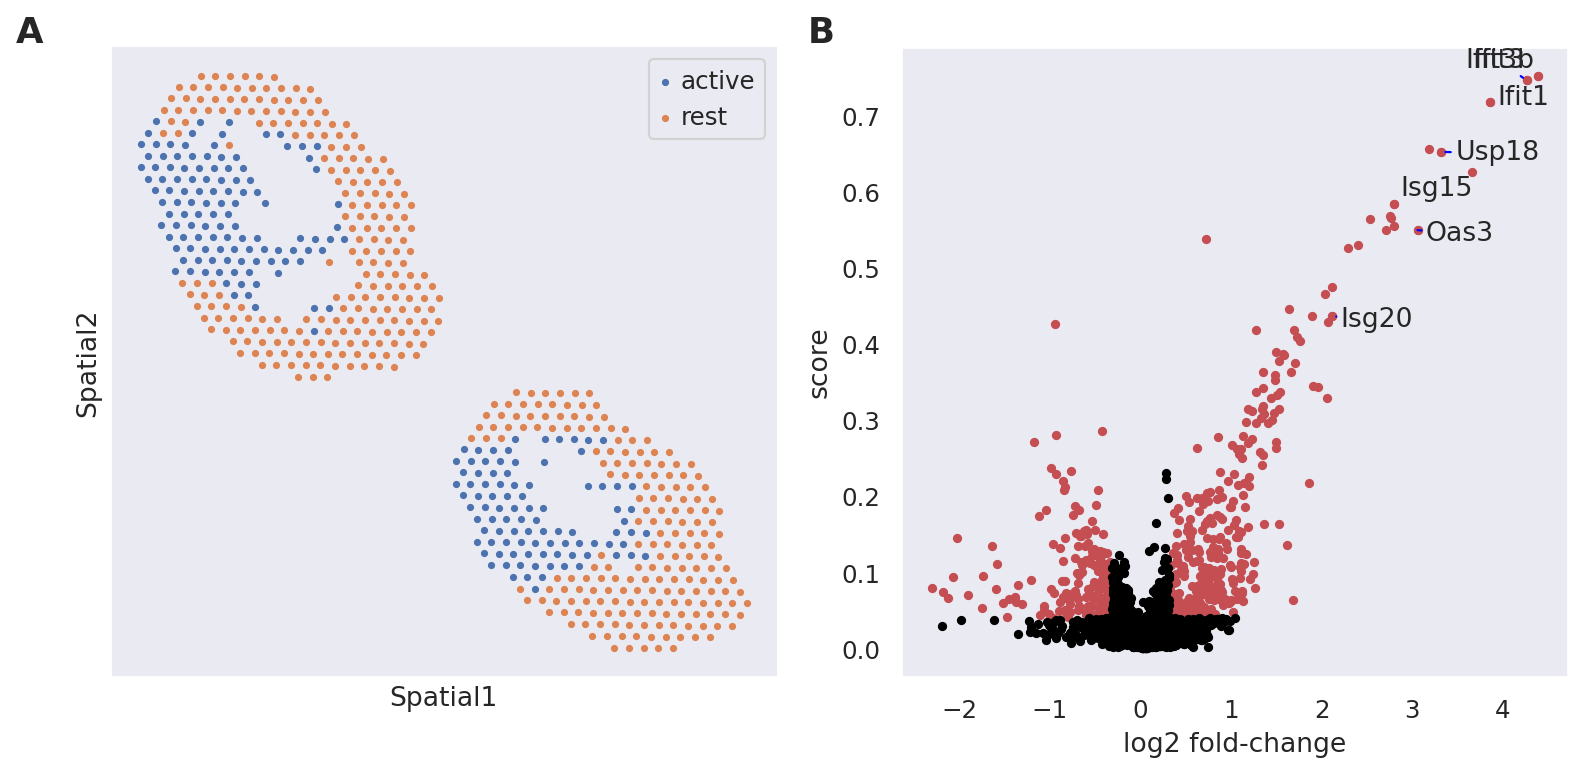

In [31]:
ct = "B cells"
imputation = st_model.get_scale_for_ct(ct)
color = np.log(1 + 1e5 * imputation["Ifit3"].values)
threshold = 4  # separates IFN-high from IFN-low B-cell spots

# IFN-rich zone: treated sections (TC or BD) with high Ifit3 expression
mask = np.logical_and(
    np.logical_or(st_adata.obs["LN"] == "TC", st_adata.obs["LN"] == "BD"),
    color > threshold,
).values

# Comparison zone: same sections but low Ifit3 expression
mask2 = np.logical_and(
    np.logical_or(st_adata.obs["LN"] == "TC", st_adata.obs["LN"] == "BD"),
    color < threshold,
).values

# Run KS test on imputed B-cell expression; results stored in st_adata.uns["IFN_rich"]
_ = destvi_utils.de_genes(
    st_model, mask=mask, mask2=mask2, threshold=ct_thresholds[ct], ct=ct, key="IFN_rich"
)

display(st_adata.uns["IFN_rich"]["de_results"].head(10))

destvi_utils.plot_de_genes(
    st_adata,
    interesting_genes=["Ifit3", "Ifit3b", "Ifit1", "Isg15", "Oas3", "Usp18", "Isg20"],
    key="IFN_rich",
)

## Step 6 — Cell-type-aware metabolic crosstalk with Harreman

Having deconvolved the spatial data with DestVI, we now use **Harreman** to infer *cell-type-aware* metabolic cell-cell communication (CCC). When a DestVI model is passed to `HarremanAnalysis`, Harreman automatically:

1. Retrieves cell-type proportions via `model.get_proportions()`.
2. Constructs proportion-weighted, cell-type-specific expression layers for every cell type.
3. Enables `ct_specific=True` mode, scoring interactions separately for each sending/receiving cell-type combination.

This contrasts with the cell-type-agnostic mode used in the Visium colon tutorial, where all expressed genes contribute equally regardless of cell type.

In [32]:
import numpy as np
from scipy.stats import zscore
from scviva.tools import HarremanAnalysis

In [33]:
# Assign the dominant cell type to each spot using Z-normalized proportions.
# Z-normalization is important: without it, abundant types (e.g., B cells) would
# always dominate regardless of local enrichment in a given spot.
proportions = st_model.get_proportions()
z_proportions = proportions.apply(zscore, axis=0)
st_adata.obs["dominant_cell_type"] = z_proportions.idxmax(axis=1)
st_adata.obs["dominant_cell_type"].value_counts()

dominant_cell_type
B cells          326
Migratory DCs    104
CD8 T cells       98
cDC1s             83
GD T cells        82
pDCs              78
Monocytes         71
cDC2s             67
Tregs             65
CD4 T cells       62
Macrophages       37
NK cells          19
Name: count, dtype: int64

In [34]:
# Passing model=st_model triggers the DestVI integration path:
# - get_proportions() is called automatically
# - proportion-weighted, cell-type-specific expression layers are attached to adata
# is_deconvolved=True confirms the DestVI layers were set up successfully
ha = HarremanAnalysis(st_adata, model=st_model)
ha.setup(
    compute_neighbors_on_key="spatial",
    species="mouse",
    database="both",  # HarremanDB (transporters) + CellChatDB (LR pairs)
    n_neighbors=5,
    cell_type_key="dominant_cell_type",
)
print(f"is_deconvolved={ha.is_deconvolved}")
print(ha)

INFO     HarremanAnalysis: attached 12 DestVI cell-type layers.                                                    


2026-07-05 10:09:44 | [INFO] HarremanAnalysis: attached 12 DestVI cell-type layers.


INFO     HarremanAnalysis: setup complete (species=mouse, database=both).                                          


2026-07-05 10:09:47 | [INFO] HarremanAnalysis: setup complete (species=mouse, database=both).


is_deconvolved=True
HarremanAnalysis(is_set_up=True, is_deconvolved=True, completed_steps=['setup'])


In [35]:
# ct_specific=True: enumerate gene pairs for each sender/receiver cell-type combination
ha.compute_gene_pairs(ct_specific=True)

In [36]:
# Infer cell-type-aware metabolic CCC:
# mode="cell_type" uses proportion-weighted expression layers
# Both parametric (DANB) and non-parametric (1000-permutation) tests are run
ha.compute_cell_communication(mode="cell_type",  n_permutations=1000, test="both")

/home/access/anaconda3/envs/scvi_new/lib/python3.13/site-packages/scviva/tools/harreman/tools/cell_communication/_ct_ccc_scoring.py:652: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  indices = torch.tensor([weights.row, weights.col], dtype=torch.long, device=device)
Permutation test: 100%|███████████████████████████████████████████████████| 1000/1000 [00:24<00:00, 40.13it/s]


In [37]:
assert ha.results.ct_cell_communication is not None  # ha.results reflects the real compute_cell_communication output

In [38]:
# Retain interactions with FDR < 0.05 (non-parametric test by default)
ha.select_significant_interactions(fdr_threshold=0.05)

### Spatial autocorrelation and metabolic module discovery

We run the Hotspot pipeline to identify **spatially co-varying metabolic gene modules**. The resulting module scores are used later to interpret which metabolic zones are linked to specific cell-type-aware interactions.

In [39]:
# Compute spatial autocorrelation restricted to mouse metabolic enzymes (DANB model)
ha.hs.compute_local_autocorrelation(
    layer_key="counts", model="danb", species="mouse", use_metabolic_genes=True
)

/home/access/anaconda3/envs/scvi_new/lib/python3.13/site-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_array is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


In [40]:
# Pairwise local correlation on all spatially autocorrelated metabolic genes
ha.hs.compute_local_correlation()

/home/access/anaconda3/envs/scvi_new/lib/python3.13/site-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_array is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


In [41]:
# Cluster genes into metabolic modules using agglomerative clustering
ha.hs.create_modules(min_gene_threshold=10)

In [42]:
# Compute per-spot module scores; device="cpu" avoids GPU memory conflicts
ha.hs.calculate_module_scores(device="cpu")

  0%|                                                                                   | 0/2 [00:00<?, ?it/s]/home/access/anaconda3/envs/scvi_new/lib/python3.13/site-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_array is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)
/home/access/anaconda3/envs/scvi_new/lib/python3.13/site-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_array is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)
100%|███████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00, 62.87it/s]


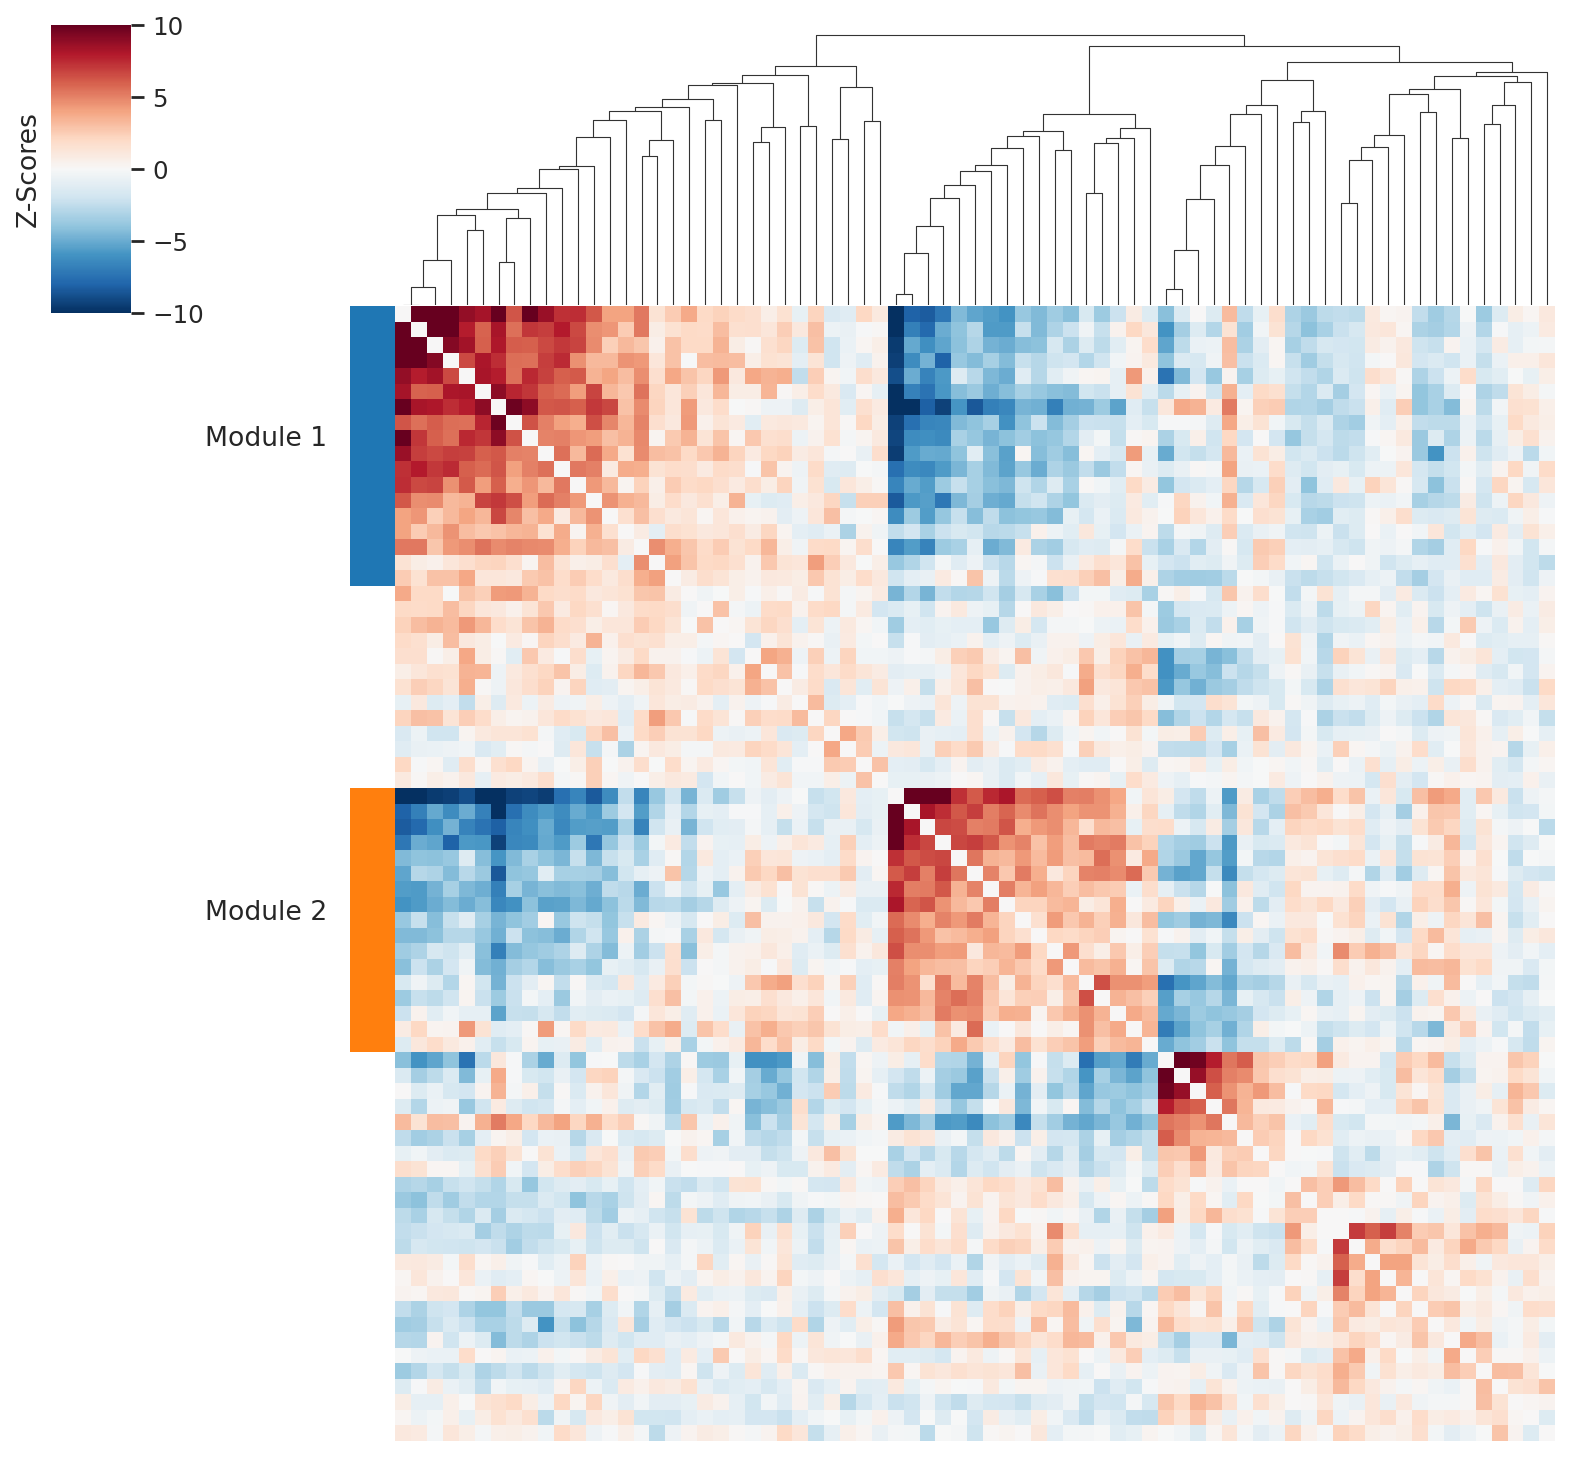

In [43]:
ha.pl.local_correlation_plot(mod_cmap="tab10")

### Correlate interaction scores with metabolic module activity

We compute per-spot interaction scores in cell-type-aware mode (`mode='cell_type'`) and Pearson-correlate them with the metabolic module scores discovered above. A high correlation indicates that a specific cell-type-aware metabolic exchange preferentially occurs in spots dominated by a particular metabolic gene program.

In [44]:
# Compute per-spot interaction scores in cell-type-aware mode
# Both parametric and non-parametric scores are computed
ha.compute_interacting_cell_scores(
    mode="cell_type", test="both", device="cpu", n_permutations=1000
)

In [45]:
# Pearson-correlate metabolite interaction scores with module scores
# ct_aware=True uses the cell-type-specific interaction scores
ha.tl.compute_interaction_module_correlation(
    cor_method="pearson",
    interaction_type="metabolite",
    test="non-parametric",
    ct_aware=True,
)

/home/access/anaconda3/envs/scvi_new/lib/python3.13/site-packages/scviva/tools/harreman/tools/cell_communication/_ccc_scoring.py:1489: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  cor_coef_df[metab] = correlation_values
/home/access/anaconda3/envs/scvi_new/lib/python3.13/site-packages/scviva/tools/harreman/tools/cell_communication/_ccc_scoring.py:1490: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  cor_pval_df[metab] = pvals
/home/access/anaconda3/envs/scvi_new/lib/python3.13/site-packages/scviva/tools/harreman/tools/cell_commun

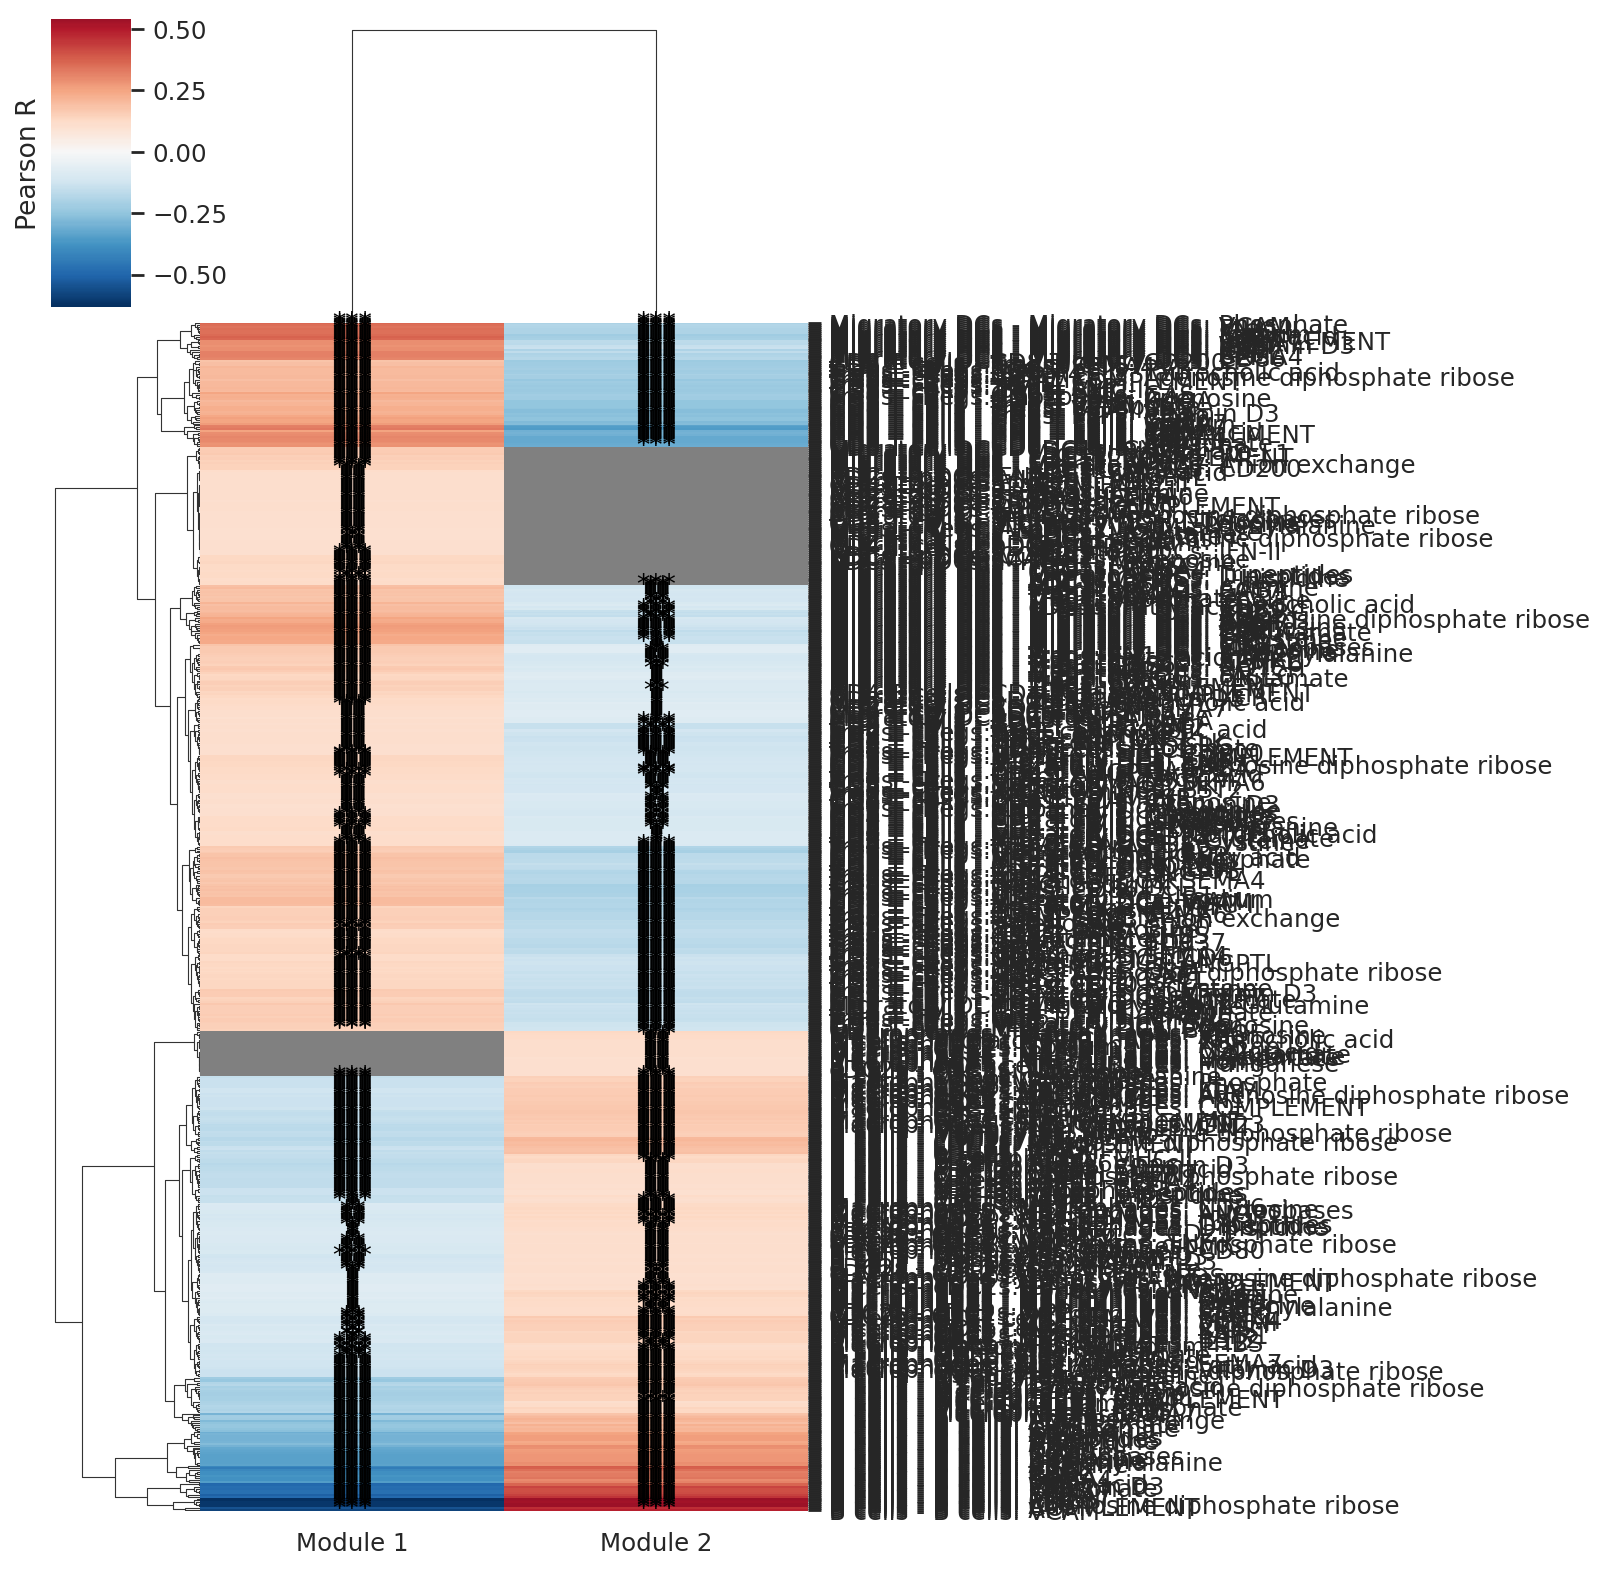

In [46]:
ha.pl.plot_interaction_module_correlation(threshold=0.1)

In [47]:
import gc

gc.collect()
import torch

torch.cuda.empty_cache()